# CT-CLIP feasibility test on our chest-CT DICOMs

**Goal.** Check whether the public CT-CLIP model (Hamamci et al., CT-RATE) is usable for our FYP:

| # | Question | Where answered |
|---|----------|----------------|
| 1 | Can it ingest our **DICOM** CTs (we convert them the way CT-CLIP expects)? | 5 |
| 2 | What does it output — **which of the 18 abnormalities** are predicted per scan? | 7 |
| 3 | Does it give **evidence maps** (where in the scan the evidence is)? | 9 |
| 4 | **Time, peak RAM and peak VRAM** for every stage + totals | 3 (instrumentation), 10 (results) |
| 5 | Does it run on **CPU only**? | 7 (`RUN_DEVICES`) + 10 |
| 6 | How well does it agree with the **report-derived labels** (CT-RATE RadBERT classifier output)? | 8 |
| 7 | One-page **summary of everything** | 10 |
| 8 | Does the same model behave the same way on **public CT-RATE scans**? (separates "the model" from "our data") | 9b |

**Runs on:** Google Colab (Drive mounted) or a Linux server. Nothing is hard-coded to one machine.

### Expected data layout
Upload this to a Drive folder (default `MyDrive/FYP_CTCLIP`; on a server: `~/FYP_CTCLIP`, or set `CTCLIP_BASE_DIR`):
```
FYP_CTCLIP/
├── dicom/                     <- copy of the "Annoymized" folder: one folder per case, e.g. 4203-26/P00001/S0001/*.dcm
├── labels.csv                 <- RadBERT binary labels (ct_id + the 18 columns)
├── predictions_summary.csv    <- (optional) RadBERT probabilities, only used for reference
└── weights/                   <- (optional) CT-CLIP_v2.pt if you already downloaded it; otherwise it is fetched from Hugging Face
```
Outputs (JSON with all timings, CSVs, figures, evidence maps) go to `FYP_CTCLIP/ctclip_test_outputs/`.

### Prerequisites
* **Hugging Face access to the gated dataset [`ibrahimhamamci/CT-RATE`](https://huggingface.co/datasets/ibrahimhamamci/CT-RATE)** (accept the terms once on the website) and a read token —
  Colab: add a secret named `HF_TOKEN`; server: `hf auth login` or `export HF_TOKEN=...`. The checkpoint is ~1.77 GB.
  Alternatively drop `CT-CLIP_v2.pt` in `FYP_CTCLIP/weights/`.
* Colab: use a GPU runtime for the GPU test. **To get a clean CPU-only measurement, run the notebook again on a CPU runtime** — the summary (§10) automatically merges the saved runs.
* No GPU / no token yet? Set `DRY_RUN_RANDOM_WEIGHTS = True` in §1 to exercise the whole pipeline (DICOM → tensors → model → timings) with random weights. Predictions are then meaningless and everything is written to a separate `dryrun` folder.

### Method notes (read once)
* **Preprocessing** replicates the official `data_inference_nii.py`: HU → clip to [−1000, 1000] → trilinear resample to (z, y, x) = 1.5 × 0.75 × 0.75 mm → /1000 → centre crop / pad (value −1) to 240 × 480 × 480.
* **Scoring** replicates the official zero-shot protocol: for each pathology two prompts, *"{name} is present."* and *"{name} is not present."*, softmax over the two image–text similarities → probability of *present*. We encode the image **once** and cache the 36 text embeddings (the official script re-encodes the image for each of the 18 pathologies). §7 verifies numerically (on the first scan) that this equals the official `CTCLIP.forward`; the result is listed in §10.
* **Axis order (checked on a real CT-RATE volume).** CT-CLIP loads a CT-RATE NIfTI as an array `(i, j, k)` whose header axis codes are `L, P, S`: axis 0 points to the patient's left (= DICOM *columns*), axis 1 to posterior (= DICOM *rows*), axis 2 to superior. The official loader hands axis 0 to the model as *height* and axis 1 as *width*, so **the model was trained on transposed slices** (spine to the right of the picture) with the slice index rising towards the head. `INPLANE_ORDER = "ctrate"` (section 1) arranges our DICOM slices the same way (z ascending by `ImagePositionPatient`, `Z_ORDER`); `"dicom"` gives the upright rows x columns picture. Sections 7-8 also score the *other* in-plane arrangement and a z-flipped copy so the sensitivity is visible, and section 9b compares against public CT-RATE scans.
* **Ground truth** = labels generated from the reports by the RadBERT classifier, not radiologist-read images. With 7 cases every metric is anecdotal — the point here is feasibility, not a benchmark.

## 1. Configuration

In [1]:
import os, sys, re, gc, io, json, time, glob, shutil, platform, subprocess, threading, warnings, contextlib, datetime as dt
from pathlib import Path
warnings.filterwarnings("ignore")

IN_COLAB = "google.colab" in sys.modules
def _env(name, default=None, cast=str):
    v = os.environ.get(name)
    return default if v in (None, "") else cast(v)

# ------------------------------ USER SETTINGS ------------------------------
RUN_DEVICES = "auto"        # "auto" -> GPU (if present) then CPU; or a list such as ["cuda"], ["cpu"], ["cuda", "cpu"]
MODEL_FILE = "CT-CLIP_v2.pt"   # zero-shot CT-CLIP. "CT_VocabFine_v2.pt" (same architecture / same code path) also works.
THRESHOLD = 0.5             # probability(present) >= THRESHOLD  ->  label predicted positive
Z_ORDER = "ascending"       # slice order fed to the model: "ascending" (foot -> head by ImagePositionPatient) or "descending"
MAX_CASES = _env("CTCLIP_MAX_CASES", None, int)      # None = all cases found
CPU_MAX_CASES = "auto"      # cases used in the CPU run. "auto": all cases if CPU is the only device, else 2 (CPU is slow)
COMPUTE_EVIDENCE_MAPS = True    # derived log-odds maps, see section 8
SWEEP_Z_FLIP = True         # also score the z-flipped volume (only on the first device, only if it is a GPU) to show orientation sensitivity
VERIFY_AGAINST_OFFICIAL = True  # numerically compare our scoring with the official CTCLIP.forward on the first case
EVIDENCE_INLINE_CASES = 3   # how many evidence-map figures are displayed inline (all are saved to disk)
DRY_RUN_RANDOM_WEIGHTS = _env("CTCLIP_DRY_RUN", "0") == "1"   # True = skip weights, random init (pipeline / timing smoke test only)
HF_TOKEN = os.environ.get("HF_TOKEN")
INPLANE_ORDER = _env("CTCLIP_INPLANE_ORDER", "ctrate")   # in-plane axis order given to the model. "ctrate" = CT-RATE NIfTI array order (what CT-CLIP was trained on: height = DICOM columns, width = DICOM rows); "dicom" = rows x columns (upright picture)
SWEEP_INPLANE = True        # also score the other in-plane arrangement (only on the first device, only if it is a GPU)
# --- public CT-RATE validation scans (section 9b). Needs HF_TOKEN and the accepted dataset terms.
RUN_CTRATE = _env("CTCLIP_RUN_CTRATE", "1") == "1"
CTRATE_N_SCANS = _env("CTCLIP_CTRATE_N", 24, int)   # how many validation scans to download and score (about 150-350 MB each)
CTRATE_MIN_POSITIVES = 3    # try to include at least this many report-positive scans for every label (stratified sample); 0 = plain random
CTRATE_SEED = 0
CTRATE_DEVICE = "auto"      # "auto" = first device of the main run
CTRATE_MAX_VOXELS = 512 * 512 * 700     # skip volumes larger than this (RAM guard for a 12 GB Colab)
CTRATE_VOLUMES = _env("CTCLIP_CTRATE_VOLUMES", None, lambda s: [x for x in s.split(",") if x])   # or an explicit list of VolumeNames, e.g. ["valid_1_a_2.nii.gz"]
# ---------------------------------------------------------------------------

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = "/content/drive/MyDrive/NHRD - Local Sample"
    WORK_DIR = "/content/ctclip_work"            # local disk: fast, but wiped when the runtime is recycled
    if not HF_TOKEN:
        try:
            from google.colab import userdata
            HF_TOKEN = userdata.get("HF_TOKEN")
        except Exception:
            pass
else:
    BASE_DIR = _env("CTCLIP_BASE_DIR", os.path.expanduser("~/FYP_CTCLIP"))
    WORK_DIR = _env("CTCLIP_WORK_DIR", os.path.expanduser("~/ctclip_work"))

DICOM_ROOT = _env("CTCLIP_DICOM_ROOT", f"{BASE_DIR}/raw/NHRD - CT Scan")
LABELS_CSV = _env("CTCLIP_LABELS_CSV", f"{BASE_DIR}/outputs/Labels/labels.csv")
PROBS_CSV = _env("CTCLIP_PROBS_CSV", f"{BASE_DIR}/outputs/predictions_summary.csv")   # optional
OUTPUT_DIR = Path(_env("CTCLIP_OUTPUT_DIR", f"{BASE_DIR}/ctclip_test_outputs")) / ("dryrun" if DRY_RUN_RANDOM_WEIGHTS else "")
WEIGHTS_DIRS = [Path(_env("CTCLIP_WEIGHTS_DIR", f"{BASE_DIR}/weights")), Path(WORK_DIR) / "weights"]
CTRATE_DIR = Path(_env("CTCLIP_CTRATE_DIR", f"{WORK_DIR}/ctrate"))     # downloaded CT-RATE files (local disk; wiped with the Colab runtime)
for d in (OUTPUT_DIR / "runs", OUTPUT_DIR / "figures", OUTPUT_DIR / "evidence_maps", Path(WORK_DIR), CTRATE_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Colab:", IN_COLAB, "| dry run:", DRY_RUN_RANDOM_WEIGHTS)
for k in ("BASE_DIR", "WORK_DIR", "DICOM_ROOT", "LABELS_CSV", "PROBS_CSV", "OUTPUT_DIR", "CTRATE_DIR"):
    print(f"{k:11s}", globals()[k])

Mounted at /content/drive
Colab: True | dry run: False
BASE_DIR    /content/drive/MyDrive/NHRD - Local Sample
WORK_DIR    /content/ctclip_work
DICOM_ROOT  /content/drive/MyDrive/NHRD - Local Sample/raw/NHRD - CT Scan
LABELS_CSV  /content/drive/MyDrive/NHRD - Local Sample/outputs/Labels/labels.csv
PROBS_CSV   /content/drive/MyDrive/NHRD - Local Sample/outputs/predictions_summary.csv
OUTPUT_DIR  /content/drive/MyDrive/NHRD - Local Sample/ctclip_test_outputs
CTRATE_DIR  /content/ctclip_work/ctrate


## 2. Environment: dependencies, CT-CLIP code, CPU patch

In [2]:
def pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

try:
    import torch
except ImportError:
    pip_install("torch"); import torch
try:
    import cv2  # noqa: F401  (imported by transformer_maskgit.data)
except ImportError:
    pip_install("opencv-python-headless")

# vector-quantize-pytorch is pinned by the CT-CLIP authors; pydicom>=3 can decode our JPEG-2000 slices through Pillow
pip_install("pydicom>=3.0", "einops>=0.6", "vector-quantize-pytorch==1.1.2", "beartype", "ema-pytorch", "accelerate",
            "nibabel", "openpyxl", "sentencepiece", "huggingface_hub", "psutil", "pandas", "matplotlib", "transformers")

def sh(*cmd):
    r = subprocess.run([str(c) for c in cmd], capture_output=True, text=True)
    if r.returncode:
        raise RuntimeError(f"{' '.join(map(str, cmd))} failed: {r.stderr}")
    return r.stdout.strip()

REPO_URL = "https://github.com/ibrahimethemhamamci/CT-CLIP.git"
REPO_COMMIT = "a2a155c601987820433c01db69b64d701d3d229d"      # version this notebook was written against
REPO_DIR = Path(WORK_DIR) / "CT-CLIP"
if not REPO_DIR.exists():
    sh("git", "clone", "--depth", "1", REPO_URL, REPO_DIR)
    try:
        sh("git", "-C", REPO_DIR, "fetch", "--depth", "1", "origin", REPO_COMMIT)
        sh("git", "-C", REPO_DIR, "checkout", "-q", "FETCH_HEAD")
    except RuntimeError:
        print("Pinned commit could not be fetched - using the latest main branch.")
REPO_HEAD = sh("git", "-C", REPO_DIR, "rev-parse", "HEAD")
print("CT-CLIP commit:", REPO_HEAD)

# The upstream code hard-codes `device=torch.device('cuda')` inside the model (attention.py, ctvit.py), so it cannot run on CPU
# (or on a specific GPU). We make it follow the env var CTCLIP_DEVICE, which we set before each run.
CUDA_PATTERN = re.compile(r"torch\.device\('cuda'\)")
CUDA_REPLACEMENT = "torch.device(__import__('os').environ.get('CTCLIP_DEVICE', 'cuda' if torch.cuda.is_available() else 'cpu'))"
n_patched = 0
for rel in ("transformer_maskgit/transformer_maskgit/attention.py", "transformer_maskgit/transformer_maskgit/ctvit.py"):
    p = REPO_DIR / rel
    s = p.read_text(encoding="utf-8")
    s, n = CUDA_PATTERN.subn(CUDA_REPLACEMENT, s)
    if n:
        p.write_text(s, encoding="utf-8")
    n_patched += n
print("hard-coded cuda devices patched this run:", n_patched, "(0 = already patched)")

sys.path[:0] = [str(REPO_DIR / "transformer_maskgit"), str(REPO_DIR / "CT_CLIP")]

import numpy as np, pandas as pd, psutil
import torch.nn.functional as F
import transformers
from transformers import BertTokenizer, BertModel
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from transformer_maskgit import CTViT
from ct_clip import CTCLIP
import pydicom
warnings.filterwarnings("ignore")
print("torch", torch.__version__, "| transformers", transformers.__version__, "| pydicom", pydicom.__version__)

CT-CLIP commit: a2a155c601987820433c01db69b64d701d3d229d
hard-coded cuda devices patched this run: 11 (0 = already patched)
torch 2.11.0+cu128 | transformers 5.16.1 | pydicom 3.0.2


## 3. Instrumentation (time, host RAM, GPU memory per stage) and hardware info

`PROF.stage(...)` wraps a block and records wall time, the **peak process RSS** during the block (sampled every 10 ms in a background thread),
and, for CUDA stages, `torch.cuda.max_memory_allocated()` / `max_memory_reserved()` since the block started (CUDA is synchronised at both ends, so times are honest).
Peak VRAM includes the model weights that are already resident; `vram_start_gb` is the resident amount, so `peak − start` is the working memory of the stage.

In [3]:
GB = 1024 ** 3
_proc = psutil.Process(os.getpid())
def rss(): return _proc.memory_info().rss

class _RssSampler(threading.Thread):
    def __init__(self, interval=0.01):
        super().__init__(daemon=True)
        self.interval, self.peak, self._halt = interval, rss(), threading.Event()
    def run(self):
        while not self._halt.is_set():
            self.peak = max(self.peak, rss())
            self._halt.wait(self.interval)
    def finish(self):
        self._halt.set(); self.join()
        return max(self.peak, rss())

class Profiler:
    def __init__(self):
        self.records = []
    @contextlib.contextmanager
    def stage(self, name, run, case="-", device="cpu"):
        """run = 'setup' | 'cuda' | 'cpu' (which benchmark run the record belongs to); device = where the computation happens."""
        cuda = device == "cuda" and torch.cuda.is_available()
        gc.collect()
        v0 = 0
        if cuda:
            torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats(); v0 = torch.cuda.memory_allocated()
        r0 = rss(); sampler = _RssSampler(); sampler.start(); t0 = time.perf_counter()
        try:
            yield
        finally:
            if cuda:
                torch.cuda.synchronize()
            secs = time.perf_counter() - t0
            peak = sampler.finish()
            rec = dict(run=run, device=device, case=str(case), stage=name, seconds=secs,
                       ram_start_gb=r0 / GB, ram_peak_gb=peak / GB, ram_delta_gb=(peak - r0) / GB,
                       vram_start_gb=np.nan, vram_peak_gb=np.nan, vram_reserved_peak_gb=np.nan)
            if cuda:
                rec.update(vram_start_gb=v0 / GB, vram_peak_gb=torch.cuda.max_memory_allocated() / GB,
                           vram_reserved_peak_gb=torch.cuda.max_memory_reserved() / GB)
            self.records.append(rec)
PROF = Profiler()

def cpu_name():
    try:
        if platform.system() == "Linux":
            for line in open("/proc/cpuinfo"):
                if line.startswith("model name"):
                    return line.split(":", 1)[1].strip()
    except Exception:
        pass
    return platform.processor() or platform.machine()

def hw_info():
    info = dict(platform=platform.platform(), python=sys.version.split()[0], cpu=cpu_name(), cpu_logical_cores=os.cpu_count(),
                ram_total_gb=round(psutil.virtual_memory().total / GB, 1), torch=torch.__version__, torch_cpu_threads=torch.get_num_threads(),
                transformers=transformers.__version__, pydicom=pydicom.__version__, ctclip_commit=REPO_HEAD[:10],
                cuda_available=torch.cuda.is_available(), gpu=None, gpu_vram_gb=None, cuda=None)
    if torch.cuda.is_available():
        pr = torch.cuda.get_device_properties(0)
        info.update(gpu=pr.name, gpu_vram_gb=round(pr.total_memory / GB, 1), cuda=torch.version.cuda)
    return info

def process_peak_rss_gb():
    try:
        import resource                                   # Linux / macOS: high-water mark of the whole process
        kb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        return kb * (1 if sys.platform == "darwin" else 1024) / GB
    except ImportError:
        return _proc.memory_info().peak_wset / GB          # Windows

HW = hw_info()
display(pd.Series(HW, name="hardware / software").to_frame())

,hardware / software
platform,Linux-6.6.122+-x86_64-with-glibc2.39
python,3.13.15
cpu,Intel(R) Xeon(R) CPU @ 2.00GHz
cpu_logical_cores,2
ram_total_gb,12.7
torch,2.11.0+cu128
torch_cpu_threads,1
transformers,5.16.1
pydicom,3.0.2
ctclip_commit,a2a155c601


## 4. Data: cases, labels, ground truth
Case folders are named like `4203-26`; `labels.csv` has ids like `4203/26` (and sometimes just `4217`). Both are keyed by their **leading number**.

In [4]:
PATHOLOGIES = ['Medical material', 'Arterial wall calcification', 'Cardiomegaly', 'Pericardial effusion',
               'Coronary artery wall calcification', 'Hiatal hernia', 'Lymphadenopathy', 'Emphysema', 'Atelectasis',
               'Lung nodule', 'Lung opacity', 'Pulmonary fibrotic sequela', 'Pleural effusion',
               'Mosaic attenuation pattern', 'Peribronchial thickening', 'Consolidation', 'Bronchiectasis',
               'Interlobular septal thickening']            # official CT-CLIP order (= CT-RATE label order)

def case_key(x):
    m = re.match(r"\s*(\d+)", str(x))
    return int(m.group(1)) if m else None

gt = pd.read_csv(LABELS_CSV)
gt["key"] = gt["ct_id"].map(case_key)
assert gt["key"].is_unique, "duplicate case numbers in labels.csv"
missing_cols = [p for p in PATHOLOGIES if p not in gt.columns]
assert not missing_cols, f"labels.csv lacks columns: {missing_cols}"
Y = gt.set_index("key")[PATHOLOGIES].astype(int)

rows = []
for d in sorted(Path(DICOM_ROOT).iterdir()):
    if d.is_dir():
        n = len(list(d.rglob("*.dcm")))
        if n:
            rows.append(dict(key=case_key(d.name), folder=d.name, path=str(d), n_slices=n, has_label=case_key(d.name) in Y.index))
cases = pd.DataFrame(rows).sort_values("key").reset_index(drop=True)
if MAX_CASES:
    cases = cases.head(MAX_CASES)
print(f"{len(cases)} DICOM cases | {int(cases.has_label.sum())} with ground-truth labels")
display(cases[["key", "folder", "n_slices", "has_label"]])
unlabelled = cases[~cases.has_label]
if len(unlabelled):
    print("WARNING - no labels for:", list(unlabelled.folder), "(they are still run, but excluded from the accuracy evaluation)")

prev = Y.loc[Y.index.intersection(cases.key)].sum().rename("positives in these cases").to_frame()
prev["of"] = len(Y.loc[Y.index.intersection(cases.key)])
display(prev[prev["positives in these cases"] > 0].sort_values("positives in these cases", ascending=False).T)
print("Labels with no positive case here can only show false positives / true negatives.")

7 DICOM cases | 7 with ground-truth labels


,key,folder,n_slices,has_label
0,4203,4203-26,363,True
1,4213,4213-26,281,True
2,4214,4214-26,432,True
3,4215,4215-26,388,True
4,4216,4216-26,413,True
5,4217,4217-26,332,True
6,4222,4222-26,376,True


,Lymphadenopathy,Bronchiectasis,Lung opacity,Lung nodule,Atelectasis,Peribronchial thickening,Mosaic attenuation pattern,Consolidation,Interlobular septal thickening,Pleural effusion,Pulmonary fibrotic sequela
positives in these cases,3,3,3,2,2,2,2,2,2,1,1
of,7,7,7,7,7,7,7,7,7,7,7


Labels with no positive case here can only show false positives / true negatives.


## 5. DICOM → CT-CLIP input tensor
On Colab the DICOMs are first copied from Drive to local disk so that Drive's per-file latency does not pollute the `dicom_read` timing (the copy itself is timed as `data_stage_in`).

DICOMs staged to /content/ctclip_work/dicom_local
case 4203-26: raw (363, 512, 512) @ spacing(z,row,col) (0.8, 0.681, 0.681) mm -> model input (1, 240, 480, 480) in 12.8s
{'n_slices': 363, 'n_series': 1, 'z_uniform': True, 'photometric': 'MONOCHROME2', 'transfer_syntax': 'JPEG 2000 Image Compression (Lossless Only)', 'iop': [1.0, 0.0, 0.0, 0.0, 1.0, 0.0]}


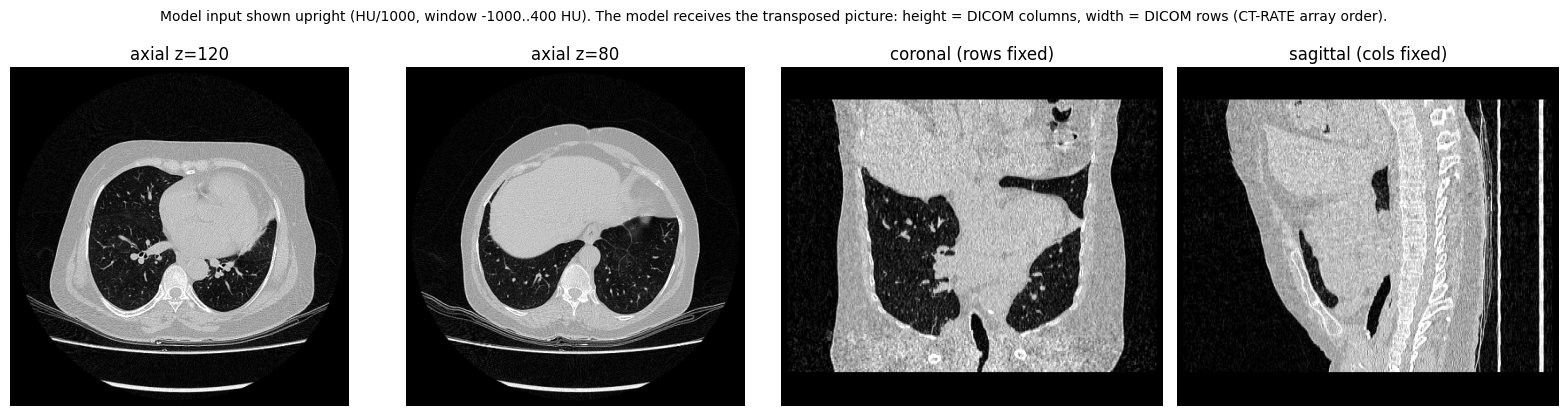

In [5]:
TARGET_SPACING = (1.5, 0.75, 0.75)      # (z, y, x) mm
TARGET_SHAPE = (240, 480, 480)          # (z, y, x) voxels

def read_dicom_volume(case_dir, z_order="ascending"):
    """Read one CT series -> float32 HU volume (Z, rows, cols) sorted by patient z, and its spacing (z, row, col) in mm."""
    ds_all = []
    for f in sorted(Path(case_dir).rglob("*.dcm")):
        ds = pydicom.dcmread(str(f))
        if getattr(ds, "Modality", "CT") == "CT" and "PixelData" in ds:
            ds_all.append(ds)
    if not ds_all:
        raise RuntimeError(f"no CT slices in {case_dir}")
    series = {}
    for ds in ds_all:
        series.setdefault(str(ds.SeriesInstanceUID), []).append(ds)
    ds_list = max(series.values(), key=len)                     # if several series exist, use the largest
    iop = np.array(ds_list[0].ImageOrientationPatient, float)
    normal = np.cross(iop[:3], iop[3:])
    ax = int(np.argmax(np.abs(normal)))                                   # world axis the slices are stacked along (2 = z for axial CT)
    pos = np.array([float(d.ImagePositionPatient[ax]) for d in ds_list])  # LPS coordinate: ascending z = towards the patient's SUPERIOR side
    order = np.argsort(pos)
    if z_order == "descending":
        order = order[::-1]
    steps = np.abs(np.diff(np.sort(pos)))
    z_sp = float(np.median(steps)) if len(steps) and np.median(steps) > 0 else float(ds_list[0].SliceThickness)
    row_sp, col_sp = (float(v) for v in ds_list[0].PixelSpacing)
    rows_, cols_ = int(ds_list[0].Rows), int(ds_list[0].Columns)
    vol = np.empty((len(ds_list), rows_, cols_), np.float32)
    for i, k in enumerate(order):
        d = ds_list[k]
        vol[i] = d.pixel_array.astype(np.float32) * float(getattr(d, "RescaleSlope", 1)) + float(getattr(d, "RescaleIntercept", 0))
    info = dict(n_slices=len(ds_list), n_series=len(series), spacing_zrc=(z_sp, row_sp, col_sp),
                z_uniform=bool(len(steps) == 0 or np.ptp(steps) < 0.1 * z_sp),
                photometric=str(ds_list[0].PhotometricInterpretation), transfer_syntax=ds_list[0].file_meta.TransferSyntaxUID.name,
                iop=[round(float(v), 4) for v in iop])
    return vol, (z_sp, row_sp, col_sp), info

def _crop_pad_axis(t, dim, target):
    n = t.shape[dim]
    start = max((n - target) // 2, 0)
    t = t.narrow(dim, start, min(start + target, n) - start)
    before = (target - t.shape[dim]) // 2
    return t, (before, target - t.shape[dim] - before)

def preprocess_volume(vol_zrc, spacing_zrc):
    """Same steps as the official data_inference_nii.py -> float32 tensor (1, 240, 480, 480), air = -1."""
    v = torch.from_numpy(np.clip(vol_zrc, -1000, 1000))[None, None]
    new_shape = [int(n * cur / tgt) for n, cur, tgt in zip(v.shape[2:], spacing_zrc, TARGET_SPACING)]
    v = F.interpolate(v, size=new_shape, mode="trilinear", align_corners=False)[0, 0] / 1000.0
    pads = []
    for dim, tgt in enumerate(TARGET_SHAPE):
        v, p = _crop_pad_axis(v, dim, tgt)
        pads.append(p)
    v = F.pad(v, (*pads[2], *pads[1], *pads[0]), value=-1.0)          # F.pad wants the last dimension first
    assert tuple(v.shape) == TARGET_SHAPE, v.shape
    return v.unsqueeze(0).contiguous()

def orient_for_model(vol_zrc, spacing_zrc, iop):
    """Arrange the in-plane axes like the CT-RATE NIfTI arrays CT-CLIP was trained on (see the intro): model height = axis pointing to the patient's LEFT
    (DICOM columns for a standard axial series), model width = axis pointing to POSTERIOR (DICOM rows). INPLANE_ORDER = "dicom" keeps rows x columns."""
    if INPLANE_ORDER == "dicom":
        return vol_zrc, spacing_zrc
    z_sp, row_sp, col_sp = spacing_zrc
    dc, dr = np.asarray(iop[:3], float), np.asarray(iop[3:], float)     # LPS direction of increasing column / row index
    if abs(dc[0]) >= abs(dr[0]):                                          # standard axial: columns run left-right, rows anterior-posterior
        out, sp, flip_h, flip_w = vol_zrc.transpose(0, 2, 1), (z_sp, col_sp, row_sp), dc[0] < 0, dr[1] < 0
    else:
        out, sp, flip_h, flip_w = vol_zrc, (z_sp, row_sp, col_sp), dr[0] < 0, dc[1] < 0
    if flip_h:
        out = out[:, ::-1]
    if flip_w:
        out = out[:, :, ::-1]
    return np.ascontiguousarray(out), sp

def coarse_volume(vol_t):
    """(1, 240, 480, 480) model input -> (30, 60, 60) block average; used to compare orientations between cohorts."""
    return F.avg_pool3d(vol_t[None], 8)[0, 0].numpy()

# --- stage the DICOMs on local disk when they live on Drive
LOCAL_DICOM = Path(WORK_DIR) / "dicom_local"
if str(DICOM_ROOT).startswith("/content/drive"):
    with PROF.stage("data_stage_in", "setup"):
        for _, r in cases.iterrows():
            dst = LOCAL_DICOM / r.folder
            if not dst.exists():
                shutil.copytree(r.path, dst)
    cases["path"] = [str(LOCAL_DICOM / f) for f in cases.folder]
    print("DICOMs staged to", LOCAL_DICOM)

# --- demo on the first case: shows what the model will actually see
_t = time.perf_counter()
_vol, _sp, _info = read_dicom_volume(cases.path[0], Z_ORDER)
_vo, _spo = orient_for_model(_vol, _sp, _info["iop"])
_x = preprocess_volume(_vo, _spo)
del _vo
print(f"case {cases.folder[0]}: raw {tuple(_vol.shape)} @ spacing(z,row,col) {tuple(round(s, 3) for s in _sp)} mm -> model input {tuple(_x.shape)} in {time.perf_counter() - _t:.1f}s")
print({k: v for k, v in _info.items() if k != "spacing_zrc"})
fig, ax = plt.subplots(1, 4, figsize=(16, 4.2))
zc, hc = TARGET_SHAPE[0] // 2, TARGET_SHAPE[1] // 2
_up = _x[0].transpose(-1, -2) if INPLANE_ORDER == "ctrate" else _x[0]      # shown upright (rows x columns) so it can be read; the model receives _x
for a, im, ttl in zip(ax, [_up[zc], _up[zc - 40], _up[:, hc, :], _up[:, :, hc]],
                      [f"axial z={zc}", f"axial z={zc - 40}", "coronal (rows fixed)", "sagittal (cols fixed)"]):
    a.imshow(im.numpy(), cmap="gray", vmin=-1, vmax=0.4, aspect="auto" if "z=" not in ttl else "equal"); a.set_title(ttl); a.axis("off")
plt.suptitle("Model input shown upright (HU/1000, window -1000..400 HU). " + ("The model receives the transposed picture: height = DICOM columns, width = DICOM rows (CT-RATE array order)."
             if INPLANE_ORDER == "ctrate" else "The model receives rows x columns (INPLANE_ORDER = dicom)."), fontsize=10); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "preprocessed_input_demo.png", dpi=110); plt.show()
del _vol, _x


## 6. Model: build, weights, inference functions
Stages timed here (one-time costs): `model_build`, `weights_download`, `weights_load`, then per device `model_to_device`, `text_encode`.

In [6]:
def l2norm(t): return F.normalize(t, dim=-1)

with PROF.stage("model_build", "setup"):
    tokenizer = BertTokenizer.from_pretrained("microsoft/BiomedVLP-CXR-BERT-specialized", do_lower_case=True)
    text_encoder = BertModel.from_pretrained("microsoft/BiomedVLP-CXR-BERT-specialized")
    text_encoder.resize_token_embeddings(len(tokenizer))
    image_encoder = CTViT(dim=512, codebook_size=8192, image_size=480, patch_size=20, temporal_patch_size=10,
                          spatial_depth=4, temporal_depth=4, dim_head=32, heads=8)
    clip = CTCLIP(image_encoder=image_encoder, text_encoder=text_encoder, dim_image=294912, dim_text=768, dim_latent=512,
                  extra_latent_projection=False, use_mlm=False, downsample_image_embeds=False, use_all_token_embeds=False)
    clip.eval()

CHECKS = {}          # numerical self-checks, reported in the summary
if DRY_RUN_RANDOM_WEIGHTS:
    torch.manual_seed(0)
    WEIGHTS_PATH = None
    print("DRY RUN: random weights, results are NOT meaningful.")
else:
    def find_weights(name):
        for d in WEIGHTS_DIRS:
            if d.exists():
                hit = next(d.rglob(name), None)
                if hit is not None:
                    return hit
    WEIGHTS_PATH = find_weights(MODEL_FILE)
    if WEIGHTS_PATH is None:
        from huggingface_hub import hf_hub_download
        with PROF.stage("weights_download", "setup"):
            WEIGHTS_PATH = Path(hf_hub_download(repo_id="ibrahimhamamci/CT-RATE", repo_type="dataset",
                                                filename=f"models/CT-CLIP-Related/{MODEL_FILE}", token=HF_TOKEN or None,
                                                local_dir=str(WEIGHTS_DIRS[1])))
    print("weights:", WEIGHTS_PATH, f"({WEIGHTS_PATH.stat().st_size / GB:.2f} GB)")
    with PROF.stage("weights_load", "setup"):
        try:
            sd = torch.load(WEIGHTS_PATH, map_location="cpu", weights_only=True)
        except Exception:                                   # older pickles; the file comes from the official repo
            sd = torch.load(WEIGHTS_PATH, map_location="cpu", weights_only=False)
        if "state_dict" in sd and isinstance(sd["state_dict"], dict):
            sd = sd["state_dict"]
        if all(k.startswith("module.") for k in sd):
            sd = {k[len("module."):]: v for k, v in sd.items()}
        res = clip.load_state_dict(sd, strict=False)
        del sd
    benign = lambda k: k.endswith(("position_ids", "token_type_ids"))     # index buffers whose persistence differs between transformers versions
    missing = [k for k in res.missing_keys if not benign(k)]
    unexpected = [k for k in res.unexpected_keys if not benign(k)]
    CHECKS["weights_missing_keys"], CHECKS["weights_unexpected_keys"] = len(missing), len(unexpected)
    model_bytes = sum(v.numel() * v.element_size() for v in clip.state_dict().values())
    print("state-dict: missing", len(missing), "| unexpected", len(unexpected), "(benign position_ids / token_type_ids ignored)")
    print(f"size check: model tensors {model_bytes / 1e9:.4f} GB vs file {WEIGHTS_PATH.stat().st_size / 1e9:.4f} GB (a gap of a few hundred KB is pickle overhead)")
    if unexpected:
        print("unexpected keys (first 5):", unexpected[:5])
    assert not missing, f"checkpoint does not match the architecture, missing e.g. {missing[:5]}"

# where the parameters (and therefore the memory) sit
def _n(m): return sum(p.numel() for p in m.parameters())
anatomy = pd.DataFrame([
    ("text encoder (CXR-BERT)", _n(clip.text_transformer), "yes"),
    ("image encoder (CTViT + VQ)", _n(clip.visual_transformer), "yes"),
    ("to_text_latent", _n(clip.to_text_latent), "yes"),
    ("to_visual_latent (294912->512)", _n(clip.to_visual_latent), "yes"),
    ("to_text_latent_extra", _n(clip.to_text_latent_extra), "no (extra_latent_projection=False)"),
    ("to_visual_latent_extra", _n(clip.to_visual_latent_extra), "no (extra_latent_projection=False)"),
], columns=["component", "params", "used at inference"])
anatomy["fp32 size (GB)"] = (anatomy.params * 4 / GB).round(3)
anatomy["params (M)"] = (anatomy.params / 1e6).round(1)
display(anatomy.drop(columns="params"))
unused_gb = anatomy.loc[anatomy["used at inference"].str.startswith("no"), "fp32 size (GB)"].sum()
print(f"total {anatomy.params.sum() / 1e6:.0f} M params | never used at inference: {unused_gb:.2f} GB of fp32 weights (could be dropped to save memory)")

tokenizer_config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/235k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  439MB            

...

models/CT-CLIP-Related/CT-CLIP_v2.pt: reconstructing file:   0%|          |  0.00B / 1.77GB            

models/CT-CLIP-Related/CT-CLIP_v2.pt: downloading bytes:           |  0.00B            

weights: /content/ctclip_work/weights/models/CT-CLIP-Related/CT-CLIP_v2.pt (1.65 GB)
state-dict: missing 0 | unexpected 0 (benign position_ids / token_type_ids ignored)
size check: model tensors 1.7694 GB vs file 1.7696 GB (a gap of a few hundred KB is pickle overhead)


,component,used at inference,fp32 size (GB),params (M)
0,text encoder (CXR-BERT),yes,0.408,109.5
1,image encoder (CTViT + VQ),yes,0.096,25.9
2,to_text_latent,yes,0.001,0.4
3,to_visual_latent (294912->512),yes,0.562,151.0
4,to_text_latent_extra,no (extra_latent_projection=False),0.001,0.4
5,to_visual_latent_extra,no (extra_latent_projection=False),0.562,151.0


total 438 M params | never used at inference: 0.56 GB of fp32 weights (could be dropped to save memory)


In [7]:
# ---- inference building blocks --------------------------------------------------------------------------------------------
PROMPTS = [f"{p} is {s}present." for p in PATHOLOGIES for s in ("", "not ")]        # 36 prompts, [present, not present] per pathology
N_PATH = len(PATHOLOGIES)

@torch.no_grad()
def encode_prompts(device):
    tok = tokenizer(PROMPTS, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
    cls = clip.text_transformer(tok.input_ids, attention_mask=tok.attention_mask)[0][:, 0, :]
    return l2norm(clip.to_text_latent(cls))                                          # (36, 512)

@torch.no_grad()
def encode_image(x):
    """x: (1,1,Z,H,W) -> encoded token grid (1,T,h,w,512); T,h,w = 24 for a 240x480x480 input."""
    return clip.visual_transformer(x, return_encoded_tokens=True)

@torch.no_grad()
def score_tokens(tokens, txt_lat):
    """Same maths as CTCLIP.forward: mean over the slice-token axis -> flatten -> linear projection -> L2 norm -> temperature-scaled similarity."""
    v = clip.to_visual_latent(tokens.mean(dim=1).reshape(tokens.shape[0], -1))         # (1, 512) un-normalised
    logits = (txt_lat @ l2norm(v).T).squeeze(1) * clip.temperature.exp()               # (36,)
    logits = logits.view(N_PATH, 2)
    return logits.softmax(dim=1)[:, 0], logits, v

@torch.no_grad()
def evidence_maps(tokens, txt_lat, logits, v):
    """Exact decomposition of each pathology's log-odds(present vs not present) over the 24x24x24 token grid.

    The image latent is linear in the slice-averaged tokens: v = W @ flatten(mean_t X). Hence  text . v = sum over tokens of
    (1/T) * text^T W_hw X_thw, i.e. every token (t,h,w) contributes an additive amount. Not part of CT-CLIP - derived here."""
    _, T, h, w, d = tokens.shape
    W = clip.to_visual_latent.weight.view(-1, h, w, d)                                  # (512, h, w, d)
    tw = torch.einsum("kl,lhwd->khwd", txt_lat, W)                                      # (36, h, w, d)
    c = torch.einsum("khwd,thwd->kthw", tw, tokens[0]) / T                              # (36, T, h, w)  contribution to the raw dot product
    scale = clip.temperature.exp() / v.norm()
    c = (c * scale).view(N_PATH, 2, T, h, w)
    delta = c[:, 0] - c[:, 1]                                                           # (18, T, h, w), sums to logit_present - logit_absent
    err = (delta.sum(dim=(1, 2, 3)) - (logits[:, 0] - logits[:, 1])).abs().max().item()
    return delta, err

def official_forward_probs(x, idx, device):
    """Ground-truth reference: the unmodified CTCLIP.forward with 512-padded prompts, as in scripts/zero_shot.py."""
    p = PATHOLOGIES[idx]
    tok = tokenizer([f"{p} is present.", f"{p} is not present."], return_tensors="pt", padding="max_length", truncation=True, max_length=512).to(device)
    with torch.no_grad(), contextlib.redirect_stdout(io.StringIO()):                   # forward() prints "test all pooling" on every call
        out = clip(tok, x, device=device)
    return out.softmax(dim=0)[0].item(), out.cpu().numpy()

## 7. Run the benchmark: GPU and/or CPU
Per scan the stages are `dicom_read` → `preprocess` → `to_device` → `image_encoder` → `projection_score` → `evidence_maps`.
The first scan on a GPU also pays CUDA / cuDNN warm-up, so the summary reports the first scan separately from the rest.

In [8]:
if RUN_DEVICES == "auto":
    DEVICES = (["cuda"] if torch.cuda.is_available() else []) + ["cpu"]
else:
    DEVICES = [d for d in RUN_DEVICES if d != "cuda" or torch.cuda.is_available()]
    if "cuda" in RUN_DEVICES and "cuda" not in DEVICES:
        print("CUDA requested but not available -> skipped")
assert DEVICES, "no device to run on: RUN_DEVICES asks for CUDA but none is available"
print("devices to run:", DEVICES)

PROBS = {}       # device -> {case key: (18,) prob(present)}
MAPS = {}        # case key -> (18, T, h, w) log-odds contribution maps (from the first device)
BG = {}          # case key -> downsampled preprocessed volume for figures
FLIP_PROBS = {}  # case key -> (18,) probs of the z-flipped volume
SWAP_PROBS = {}  # case key -> (18,) probs with the other in-plane arrangement (h/w swapped)
COARSE_LOCAL = {}  # case key -> (30, 60, 60) block-averaged model input, for the orientation comparison in section 9b
SPACINGS = {}
CASE_INFO = {}

def run_device(device, case_rows, primary):
    os.environ["CTCLIP_DEVICE"] = device
    with PROF.stage("model_to_device", device, device=device):
        clip.to(device)
    with PROF.stage("text_encode", device, device=device):
        txt = encode_prompts(device)
    PROBS[device] = {}
    for n_done, r in enumerate(case_rows.itertuples(), 1):
        k = r.key
        print(f"[{device}] case {r.folder} ({n_done}/{len(case_rows)}) ...", end=" ", flush=True)
        with PROF.stage("dicom_read", device, case=k):
            vol, spacing, info = read_dicom_volume(r.path, Z_ORDER)
        SPACINGS[k], CASE_INFO[k] = spacing, info
        with PROF.stage("preprocess", device, case=k):
            vol_o, spacing_o = orient_for_model(vol, spacing, info["iop"])
            vol_t = preprocess_volume(vol_o, spacing_o)
        del vol, vol_o
        COARSE_LOCAL[k] = coarse_volume(vol_t)
        with PROF.stage("to_device", device, case=k, device=device):
            x = vol_t[None].to(device)
        with PROF.stage("image_encoder", device, case=k, device=device):
            tokens = encode_image(x)
        with PROF.stage("projection_score", device, case=k, device=device):
            probs, logits, v = score_tokens(tokens, txt)
            probs_np = probs.float().cpu().numpy()
        PROBS[device][k] = probs_np
        if primary and COMPUTE_EVIDENCE_MAPS:
            with PROF.stage("evidence_maps", device, case=k, device=device):
                delta, err = evidence_maps(tokens, txt, logits, v)
                MAPS[k] = delta.float().cpu().numpy()
            CHECKS["evidence_decomposition_max_abs_err"] = max(CHECKS.get("evidence_decomposition_max_abs_err", 0.0), err)
            BG[k] = F.avg_pool2d(vol_t, 2).numpy().astype(np.float16)[0]           # (240, 240, 240) for the figures
            np.savez_compressed(OUTPUT_DIR / "evidence_maps" / f"{k}.npz", maps=MAPS[k].astype(np.float16), pathologies=PATHOLOGIES)
        # ---- checks and sweeps: deliberately outside the benchmark stages
        if primary and VERIFY_AGAINST_OFFICIAL and "official_forward_max_abs_prob_diff" not in CHECKS:
            i = PATHOLOGIES.index("Atelectasis")
            p_off, _ = official_forward_probs(x, i, device)
            CHECKS["official_forward_max_abs_prob_diff"] = abs(p_off - float(probs_np[i]))
            print(f"[verify] official forward p={p_off:.5f} vs ours p={probs_np[i]:.5f}", end=" ")
        if primary and SWEEP_Z_FLIP and device == "cuda":
            with torch.no_grad():
                FLIP_PROBS[k] = score_tokens(encode_image(torch.flip(x, dims=[2])), txt)[0].float().cpu().numpy()
        if primary and SWEEP_INPLANE and device == "cuda":
            with torch.no_grad():
                SWAP_PROBS[k] = score_tokens(encode_image(x.transpose(-1, -2).contiguous()), txt)[0].float().cpu().numpy()
        t_case = sum(rec["seconds"] for rec in PROF.records if rec["run"] == device and rec["case"] == str(k)
                     and rec["stage"] in ("dicom_read", "preprocess", "to_device", "image_encoder", "projection_score", "evidence_maps"))
        print(f"{t_case:.1f}s")
        del x, tokens, vol_t
        if device == "cuda":
            torch.cuda.empty_cache()

def save_run(device):
    recs = [r for r in PROF.records if r["run"] in ("setup", device)]
    payload = dict(saved=dt.datetime.now().isoformat(timespec="seconds"), device=device, dry_run=DRY_RUN_RANDOM_WEIGHTS, model_file=MODEL_FILE,
                   hardware=HW, config=dict(threshold=THRESHOLD, cases=[int(k) for k in PROBS[device]], inplane_order=INPLANE_ORDER, z_order=Z_ORDER),
                   process_peak_rss_gb=process_peak_rss_gb(), checks=CHECKS, records=recs,
                   probs={str(k): v.tolist() for k, v in PROBS[device].items()},
                   probs_zflip=({str(k): v.tolist() for k, v in FLIP_PROBS.items()} if FLIP_PROBS and device == DEVICES[0] else None),
                   probs_inplane_alt=({str(k): v.tolist() for k, v in SWAP_PROBS.items()} if SWAP_PROBS and device == DEVICES[0] else None))
    path = OUTPUT_DIR / "runs" / f"run_{device}_{dt.datetime.now():%Y%m%d_%H%M%S}.json"
    path.write_text(json.dumps(payload, default=float, indent=1))
    pd.DataFrame(PROBS[device], index=PATHOLOGIES).T.rename_axis("case").to_csv(OUTPUT_DIR / f"probabilities_{device}.csv")
    if FLIP_PROBS and device == DEVICES[0]:                      # z-flipped volume scored in this run -> keep it next to the normal predictions
        pd.DataFrame(FLIP_PROBS, index=PATHOLOGIES).T.rename_axis("case").to_csv(OUTPUT_DIR / f"probabilities_{device}_zflip.csv")
    if SWAP_PROBS and device == DEVICES[0]:                      # the other in-plane arrangement, scored in the same run
        pd.DataFrame(SWAP_PROBS, index=PATHOLOGIES).T.rename_axis("case").to_csv(OUTPUT_DIR / f"probabilities_{device}_inplane_alt.csv")
    return path

for i, device in enumerate(DEVICES):
    sel = cases
    if device == "cpu":
        n_cpu = (len(cases) if len(DEVICES) == 1 else 2) if CPU_MAX_CASES == "auto" else CPU_MAX_CASES
        sel = cases.head(n_cpu) if n_cpu else cases.head(0)
    if len(sel) == 0:
        continue
    print(f"\n=== run on {device.upper()} ({len(sel)} cases) ===")
    run_device(device, sel, primary=(i == 0))
    print("saved:", save_run(device))
    if device == "cuda":
        clip.to("cpu"); torch.cuda.empty_cache()                # leave the model on CPU before the CPU run (frees VRAM)

PRIMARY = DEVICES[0]
print("\nchecks so far:", {k: (round(v, 6) if isinstance(v, float) else v) for k, v in CHECKS.items()})

devices to run: ['cuda', 'cpu']

=== run on CUDA (7 cases) ===
[cuda] case 4203-26 (1/7) ... [verify] official forward p=0.48750 vs ours p=0.48750 30.0s
[cuda] case 4213-26 (2/7) ... 2.8s
[cuda] case 4214-26 (3/7) ... 43.6s
[cuda] case 4215-26 (4/7) ... 3.8s
[cuda] case 4216-26 (5/7) ... 4.5s
[cuda] case 4217-26 (6/7) ... 2.9s
[cuda] case 4222-26 (7/7) ... 44.2s
saved: /content/drive/MyDrive/NHRD - Local Sample/ctclip_test_outputs/runs/run_cuda_20260923_051454.json

=== run on CPU (2 cases) ===
[cpu] case 4203-26 (1/2) ... 32.1s
[cpu] case 4213-26 (2/2) ... 25.2s
saved: /content/drive/MyDrive/NHRD - Local Sample/ctclip_test_outputs/runs/run_cpu_20260923_051600.json

checks so far: {'weights_missing_keys': 0, 'weights_unexpected_keys': 0, 'evidence_decomposition_max_abs_err': 1e-06, 'official_forward_max_abs_prob_diff': 0.0}


### Predicted abnormalities (out of 18) per scan
`p` = probability of *"{pathology} is present"* from the two-prompt softmax. Predicted positive when `p ≥ THRESHOLD`.
`TP / FP / FN` compare with the report-derived label (RadBERT).

In [9]:
P = pd.DataFrame(PROBS[PRIMARY], index=PATHOLOGIES).T.rename_axis("case")          # cases x 18
Pbin = (P >= THRESHOLD).astype(int)
common = P.index.intersection(Y.index)
print(f"predictions from: {PRIMARY.upper()} run | weights: {'RANDOM (dry run)' if DRY_RUN_RANDOM_WEIGHTS else MODEL_FILE}\n")
for k in P.index:
    pred = [p for p in PATHOLOGIES if Pbin.loc[k, p]]
    line = f"case {k}: {len(pred)}/18 predicted positive -> " + (", ".join(f"{p} ({P.loc[k, p]:.2f})" for p in pred) or "none")
    print(line)
    if k in Y.index:
        truth = [p for p in PATHOLOGIES if Y.loc[k, p]]
        tp = [p for p in pred if p in truth]; fp = [p for p in pred if p not in truth]; fn = [p for p in truth if p not in pred]
        print(f"         report labels ({len(truth)}): {', '.join(truth) or 'none'}")
        print(f"         TP {len(tp)} | FP {len(fp)}: {', '.join(fp) or '-'} | FN {len(fn)}: {', '.join(fn) or '-'}")
    else:
        print("         (no report label available)")
display(P.round(3))

predictions from: CUDA run | weights: CT-CLIP_v2.pt

case 4203: 3/18 predicted positive -> Cardiomegaly (0.53), Pericardial effusion (0.52), Hiatal hernia (0.52)
         report labels (2): Atelectasis, Mosaic attenuation pattern
         TP 0 | FP 3: Cardiomegaly, Pericardial effusion, Hiatal hernia | FN 2: Atelectasis, Mosaic attenuation pattern
case 4213: 1/18 predicted positive -> Mosaic attenuation pattern (0.52)
         report labels (5): Lymphadenopathy, Lung opacity, Mosaic attenuation pattern, Peribronchial thickening, Interlobular septal thickening
         TP 1 | FP 0: - | FN 4: Lymphadenopathy, Lung opacity, Peribronchial thickening, Interlobular septal thickening
case 4214: 13/18 predicted positive -> Medical material (0.57), Arterial wall calcification (0.52), Cardiomegaly (0.57), Pericardial effusion (0.70), Hiatal hernia (0.54), Lymphadenopathy (0.66), Lung nodule (0.51), Lung opacity (0.71), Pulmonary fibrotic sequela (0.71), Pleural effusion (0.71), Mosaic attenuatio

,Medical material,Arterial wall calcification,Cardiomegaly,Pericardial effusion,Coronary artery wall calcification,Hiatal hernia,Lymphadenopathy,Emphysema,Atelectasis,Lung nodule,Lung opacity,Pulmonary fibrotic sequela,Pleural effusion,Mosaic attenuation pattern,Peribronchial thickening,Consolidation,Bronchiectasis,Interlobular septal thickening
case,,,,,,,,,,,,,,,,,,
4203,0.392,0.493,0.528,0.521,0.499,0.517,0.382,0.412,0.488,0.419,0.375,0.276,0.315,0.453,0.411,0.327,0.328,0.396
4213,0.346,0.423,0.384,0.332,0.446,0.358,0.322,0.355,0.414,0.308,0.303,0.351,0.247,0.518,0.407,0.256,0.307,0.476
4214,0.567,0.524,0.571,0.704,0.487,0.539,0.658,0.463,0.497,0.506,0.707,0.711,0.709,0.636,0.477,0.727,0.409,0.646
4215,0.451,0.503,0.439,0.357,0.521,0.491,0.483,0.474,0.479,0.440,0.483,0.573,0.329,0.607,0.559,0.362,0.515,0.613
4216,0.300,0.311,0.250,0.213,0.357,0.278,0.168,0.381,0.397,0.321,0.267,0.235,0.301,0.349,0.369,0.265,0.364,0.291
4217,0.392,0.474,0.373,0.319,0.522,0.467,0.418,0.433,0.414,0.423,0.262,0.355,0.154,0.478,0.523,0.175,0.510,0.497
4222,0.547,0.595,0.521,0.482,0.591,0.612,0.678,0.551,0.546,0.560,0.598,0.705,0.436,0.616,0.638,0.490,0.640,0.666


## 8. Evaluation against the report-derived labels

,"CUDA run, threshold 0.5"
n_cases,7.000
n_label_decisions,126.000
n_positive_labels,23.000
accuracy,0.627
accuracy_if_all_negative,0.817
micro_precision,0.214
micro_recall,0.391
micro_F1,0.277
macro_F1_over_labels_with_positives,0.382
micro_AUROC,0.557


,support,pred_pos,TP,FP,FN,TN,precision,recall,F1,AUROC
label,,,,,,,,,,
Medical material,0,2,0,2,0,5,0.000,NaN,0.000,NaN
Arterial wall calcification,0,3,0,3,0,4,0.000,NaN,0.000,NaN
Cardiomegaly,0,3,0,3,0,4,0.000,NaN,0.000,NaN
Pericardial effusion,0,2,0,2,0,5,0.000,NaN,0.000,NaN
Coronary artery wall calcification,0,3,0,3,0,4,0.000,NaN,0.000,NaN
Hiatal hernia,0,3,0,3,0,4,0.000,NaN,0.000,NaN
Lymphadenopathy,3,2,1,1,2,3,0.500,0.333,0.400,0.583
Emphysema,0,1,0,1,0,6,0.000,NaN,0.000,NaN
Atelectasis,2,1,0,1,2,4,0.000,0.000,0.000,0.800



Borderline report labels (RadBERT probability between 0.2 and 0.8): 10 of 126


,label,radbert_p,report_label,ctclip_p
case,,,,
4213,Lung opacity,0.774,1,0.303
4213,Mosaic attenuation pattern,0.525,1,0.518
4214,Emphysema,0.211,0,0.463
4214,Interlobular septal thickening,0.589,1,0.646
4216,Lung opacity,0.764,1,0.267
4216,Peribronchial thickening,0.653,1,0.369
4217,Lung opacity,0.236,0,0.262
4217,Pulmonary fibrotic sequela,0.341,0,0.355
4222,Lung opacity,0.504,1,0.598


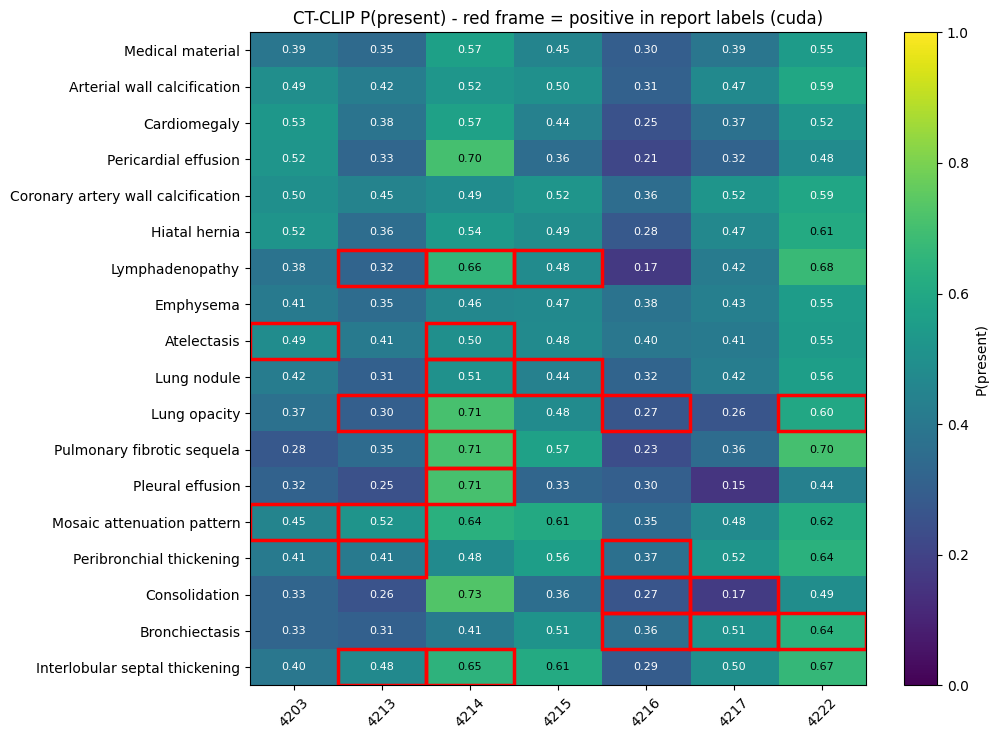

,accuracy,micro_precision,micro_recall,micro_F1
threshold,,,,
0.10,0.183,0.183,1.000,0.309
0.25,0.214,0.183,0.957,0.308
0.50,0.627,0.214,0.391,0.277
0.75,0.817,NaN,0.000,0.000
0.90,0.817,NaN,0.000,0.000


In [10]:
def auroc(y, s):
    y, s = np.asarray(y), np.asarray(s, float)
    n1, n0 = int((y == 1).sum()), int((y == 0).sum())
    if n1 == 0 or n0 == 0:
        return np.nan
    r = pd.Series(s).rank().to_numpy()
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

def avg_precision(y, s):
    y, s = np.asarray(y), np.asarray(s, float)
    if y.sum() == 0:
        return np.nan
    o = np.argsort(-s, kind="stable"); y = y[o]
    return float((np.cumsum(y) / np.arange(1, len(y) + 1))[y == 1].mean())

def prf(tp, fp, fn):
    prec = tp / (tp + fp) if tp + fp else np.nan
    rec = tp / (tp + fn) if tp + fn else np.nan
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else np.nan
    return prec, rec, f1

def evaluate(Pm, Ym, thr):
    Pm, Ym = Pm.loc[Ym.index.intersection(Pm.index)], Ym.loc[Ym.index.intersection(Pm.index)]
    B = (Pm >= thr).astype(int)
    per = []
    for p in PATHOLOGIES:
        y, b = Ym[p].to_numpy(), B[p].to_numpy()
        tp, fp, fn, tn = int(((b == 1) & (y == 1)).sum()), int(((b == 1) & (y == 0)).sum()), int(((b == 0) & (y == 1)).sum()), int(((b == 0) & (y == 0)).sum())
        pr, rc, f1 = prf(tp, fp, fn)
        per.append(dict(label=p, support=int(y.sum()), pred_pos=int(b.sum()), TP=tp, FP=fp, FN=fn, TN=tn, precision=pr, recall=rc, F1=f1, AUROC=auroc(y, Pm[p])))
    per = pd.DataFrame(per).set_index("label")
    tp, fp, fn, tn = per.TP.sum(), per.FP.sum(), per.FN.sum(), per.TN.sum()
    pr, rc, f1 = prf(tp, fp, fn)
    ally, alls = Ym.to_numpy().ravel(), Pm.to_numpy().ravel()
    per_case_f1 = [prf(*[int(v) for v in (((B.loc[k] == 1) & (Ym.loc[k] == 1)).sum(), ((B.loc[k] == 1) & (Ym.loc[k] == 0)).sum(), ((B.loc[k] == 0) & (Ym.loc[k] == 1)).sum())])[2] for k in Ym.index]
    overall = dict(n_cases=len(Ym), n_label_decisions=int(ally.size), n_positive_labels=int(ally.sum()),
                   accuracy=(tp + tn) / (tp + tn + fp + fn), accuracy_if_all_negative=1 - ally.mean(),
                   micro_precision=pr, micro_recall=rc, micro_F1=f1,
                   macro_F1_over_labels_with_positives=per.loc[per.support > 0, "F1"].mean(),
                   micro_AUROC=auroc(ally, alls), micro_AP=avg_precision(ally, alls),
                   mean_prob_on_positive_labels=float(alls[ally == 1].mean()) if ally.sum() else np.nan,
                   mean_prob_on_negative_labels=float(alls[ally == 0].mean()),
                   mean_case_F1=float(np.nanmean(per_case_f1)))
    return per, overall, B

if len(common):
    per_label, overall, Bcm = evaluate(P, Y, THRESHOLD)
    display(pd.Series(overall, name=f"{PRIMARY.upper()} run, threshold {THRESHOLD}").round(3).to_frame())
    display(per_label.round(3))
    per_label.round(4).to_csv(OUTPUT_DIR / "per_label_metrics.csv")

    # how trustworthy is the "ground truth"? RadBERT probabilities close to 0.5 mean the report-derived label itself is borderline
    if Path(PROBS_CSV).exists():
        rb = pd.read_csv(PROBS_CSV)
        rb["key"] = rb["report_id"].map(case_key)
        RB = rb.set_index("key")[PATHOLOGIES]
        unc = [dict(case=k, label=p, radbert_p=RB.loc[k, p], report_label=int(Y.loc[k, p]), ctclip_p=P.loc[k, p])
               for k in common if k in RB.index for p in PATHOLOGIES if 0.2 <= RB.loc[k, p] <= 0.8]
        print(f"\nBorderline report labels (RadBERT probability between 0.2 and 0.8): {len(unc)} of {len(common) * N_PATH}")
        if unc:
            display(pd.DataFrame(unc).round(3).set_index("case"))

    # probability heat-map with ground truth marked
    Pm, Ym = P.loc[common], Y.loc[common]
    fig, ax = plt.subplots(figsize=(max(8.5, 5.5 + 0.7 * len(common)), 7.5))
    im = ax.imshow(Pm.T.to_numpy(), cmap="viridis", vmin=0, vmax=1, aspect="auto")
    for i, p in enumerate(PATHOLOGIES):
        for j, k in enumerate(common):
            if Ym.loc[k, p]:
                ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False, ec="red", lw=2.5))
            ax.text(j, i, f"{Pm.loc[k, p]:.2f}", ha="center", va="center", fontsize=8, color="white" if Pm.loc[k, p] < .6 else "black")
    ax.set_xticks(range(len(common))); ax.set_xticklabels(common, rotation=45); ax.set_yticks(range(N_PATH)); ax.set_yticklabels(PATHOLOGIES)
    ax.set_title(f"CT-CLIP P(present) - red frame = positive in report labels ({PRIMARY})"); plt.colorbar(im, label="P(present)")
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / "figures" / "probability_heatmap.png", dpi=110); plt.show()

    # threshold sensitivity (pooled over cases and labels)
    sweep = [dict(threshold=t, **{k: v for k, v in evaluate(P, Y, t)[1].items() if k in ("micro_precision", "micro_recall", "micro_F1", "accuracy")}) for t in (0.1, 0.25, 0.5, 0.75, 0.9)]
    display(pd.DataFrame(sweep).set_index("threshold").round(3))
else:
    per_label, overall = None, None
    print("No case has a ground-truth label - evaluation skipped.")

### 8b. Prior-corrected, threshold-free metrics
Zero-shot CT-CLIP gives each label its own near-constant offset (some labels are above 0.5 on almost every scan, others on none). That offset is not image information, and it wrecks any fixed threshold and inflates or deflates *pooled* metrics that mix labels. Here we
1. convert `P(present)` to logits and subtract each label's mean logit over the scans (**prior-corrected** = what the image changes *relative to that label's usual level*),
2. compare it with the raw probability and with a **label-prior-only** score (each label's mean, identical for every scan = no image information at all).

Read it as: *raw vs label-prior-only* shows how much of the pooled score is just the prior; *prior-corrected* shows what is left that depends on the scan. Per-label AUROC is identical for raw and corrected (subtracting a constant per label cannot change a label's ranking). The label mean is estimated from the same few scans, so this is a diagnostic, not a benchmark, and with 1-3 positives per label every number is noisy.

In [11]:
def _logit(p):
    p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def prior_correct(S):
    """logit(P) minus each label's mean logit over the scans in S."""
    L = pd.DataFrame(_logit(S.to_numpy()), index=S.index, columns=S.columns)
    return L - L.mean(axis=0)

def prior_only(S):
    """Each label's mean logit repeated for every scan: no image information at all."""
    L = pd.DataFrame(_logit(S.to_numpy()), index=S.index, columns=S.columns)
    return L * 0 + L.mean(axis=0)

def threshold_free_metrics(S, Ym):
    """S = scores (scans x 18); no decision threshold involved."""
    per_label = np.array([auroc(Ym[p], S[p]) for p in PATHOLOGIES], float)
    per_scan = np.array([auroc(Ym.loc[k], S.loc[k]) for k in Ym.index], float)
    mean_ok = lambda a: float(np.nanmean(a)) if np.isfinite(a).any() else np.nan
    y_all, s_all = Ym.to_numpy().ravel(), S.to_numpy().ravel()
    return {"pooled_AUROC": auroc(y_all, s_all), "pooled_AP": avg_precision(y_all, s_all),
            "mean_per_label_AUROC": mean_ok(per_label), "labels_with_both_classes": int(np.isfinite(per_label).sum()),
            "mean_within_scan_AUROC": mean_ok(per_scan)}

PC = {}
if len(common) >= 2:
    Pm, Ym = P.loc[common], Y.loc[common]
    L = pd.DataFrame(_logit(Pm.to_numpy()), index=Pm.index, columns=Pm.columns)
    prior = L.mean(axis=0)                                            # each label's average logit over these scans
    PC = {"raw probability": threshold_free_metrics(Pm, Ym),
          "prior-corrected (logit - label mean)": threshold_free_metrics(L - prior, Ym),
          "label prior only (no image info)": threshold_free_metrics(L * 0 + prior, Ym)}
    display(pd.DataFrame(PC).round(3))
    pd.DataFrame(PC).round(4).to_csv(OUTPUT_DIR / "prior_corrected_metrics.csv")
    spread_between = float(prior.var()); spread_within = float((L - prior).pow(2).to_numpy().mean())
    print(f"variance of the logits: between labels {spread_between:.3f} vs across scans within a label {spread_within:.3f} "
          f"-> the label offset is {spread_between / spread_within:.1f}x larger than the scan-to-scan variation")
else:
    print("need at least 2 scans with labels")


,raw probability,prior-corrected (logit - label mean),label prior only (no image info)
pooled_AUROC,0.557,0.530,0.484
pooled_AP,0.269,0.258,0.270
mean_per_label_AUROC,0.577,0.577,0.500
labels_with_both_classes,11.000,11.000,11.000
mean_within_scan_AUROC,0.586,0.615,0.465


variance of the logits: between labels 0.035 vs across scans within a label 0.278 -> the label offset is 0.1x larger than the scan-to-scan variation


In [12]:
# ---- CPU vs GPU parity, and z-flip sensitivity (only when those runs exist) --------------------------------------------------
if "cuda" in PROBS and "cpu" in PROBS:
    ks = [k for k in PROBS["cpu"] if k in PROBS["cuda"]]
    CHECKS["cpu_vs_gpu_max_abs_prob_diff"] = float(max(np.abs(PROBS["cpu"][k] - PROBS["cuda"][k]).max() for k in ks))
    print(f"CPU vs GPU on {len(ks)} case(s): max |dP| = {CHECKS['cpu_vs_gpu_max_abs_prob_diff']:.2e}")

if FLIP_PROBS:
    Pf = pd.DataFrame(FLIP_PROBS, index=PATHOLOGIES).T
    CHECKS["zflip_mean_abs_prob_change"] = float((Pf.loc[P.index] - P).abs().to_numpy().mean())
    print(f"z-flipped volume: mean |dP| = {CHECKS['zflip_mean_abs_prob_change']:.3f} over all case/label pairs")
    if len(common):
        _, ov_flip, _ = evaluate(Pf, Y, THRESHOLD)
        zcmp = pd.DataFrame({"z ascending (default)": overall, "z flipped": ov_flip}).loc[["micro_AUROC", "micro_AP", "micro_F1", "accuracy"]].round(3)
        display(zcmp)
        zcmp.to_csv(OUTPUT_DIR / "zflip_comparison.csv")
        print("If the two columns differ a lot, the model is orientation-sensitive: try Z_ORDER = 'descending' in section 1 and compare.")

if SWAP_PROBS:
    Ps = pd.DataFrame(SWAP_PROBS, index=PATHOLOGIES).T
    ALT = "DICOM rows x columns" if INPLANE_ORDER == "ctrate" else "CT-RATE array order (h/w swapped)"
    CHECKS["inplane_alt_mean_abs_prob_change"] = float((Ps.loc[P.index] - P).abs().to_numpy().mean())
    print(f"other in-plane arrangement ({ALT}): mean |dP| = {CHECKS['inplane_alt_mean_abs_prob_change']:.3f} over all case/label pairs")
    if len(common):
        cur_tf, alt_tf = threshold_free_metrics(prior_correct(P.loc[common]), Y.loc[common]), threshold_free_metrics(prior_correct(Ps.loc[common]), Y.loc[common])
        _, ov_swap, _ = evaluate(Ps, Y, THRESHOLD)
        scmp = pd.DataFrame({f"current: {INPLANE_ORDER}": {**{k: overall[k] for k in ["micro_AUROC", "micro_AP", "micro_F1", "accuracy"]}, "prior-corrected pooled AUROC": cur_tf["pooled_AUROC"],
                                                            "mean per-label AUROC": cur_tf["mean_per_label_AUROC"]},
                             f"alternative: {ALT}": {**{k: ov_swap[k] for k in ["micro_AUROC", "micro_AP", "micro_F1", "accuracy"]}, "prior-corrected pooled AUROC": alt_tf["pooled_AUROC"],
                                                     "mean per-label AUROC": alt_tf["mean_per_label_AUROC"]}}).round(3)
        display(scmp)
        scmp.to_csv(OUTPUT_DIR / "inplane_order_comparison.csv")
        print("Section 9b tells which arrangement CT-RATE volumes have; this table shows how much it matters for our scans.")


CPU vs GPU on 2 case(s): max |dP| = 3.58e-07
z-flipped volume: mean |dP| = 0.139 over all case/label pairs


,z ascending (default),z flipped
micro_AUROC,0.557,0.554
micro_AP,0.269,0.241
micro_F1,0.277,0.291
accuracy,0.627,0.381


If the two columns differ a lot, the model is orientation-sensitive: try Z_ORDER = 'descending' in section 1 and compare.
other in-plane arrangement (DICOM rows x columns): mean |dP| = 0.161 over all case/label pairs


,current: ctrate,alternative: DICOM rows x columns
micro_AUROC,0.557,0.451
micro_AP,0.269,0.211
micro_F1,0.277,0.280
accuracy,0.627,0.389
prior-corrected pooled AUROC,0.530,0.629
mean per-label AUROC,0.577,0.706


Section 9b tells which arrangement CT-RATE volumes have; this table shows how much it matters for our scans.


## 9. Evidence maps — does CT-CLIP give them?
**Official model: no.** `CTCLIP.forward` returns only volume-level image–text similarities (or, with `return_latents=True`, the latents plus the raw 24×24×24×512 token grid). There is no attention rollout, CAM or localisation output, and the paper reports classification / retrieval only.

**What we can derive (experimental, ours, not from the paper).** The volume embedding is a *linear* function of the slice-averaged tokens, so the log-odds `logit(present) − logit(not present)` of every pathology splits **exactly** into one additive contribution per token of the 24×24×24 grid (each cell ≈ 15 mm × 15 mm × 15 mm of the resampled scan). The check `evidence_decomposition_max_abs_err` in the summary proves the parts add up to the model's own logit.
Red = token pushes towards *present*, blue = towards *not present*.

**Limits, stated plainly:** (1) this shows where the *final feature grid* carries evidence, not causal pixels — each token has already mixed information from the whole scan through self-attention; (2) the grid is coarse (15 mm); (3) we have no lesion masks, so **localisation accuracy cannot be scored here** — treat it as a qualitative plausibility check only.

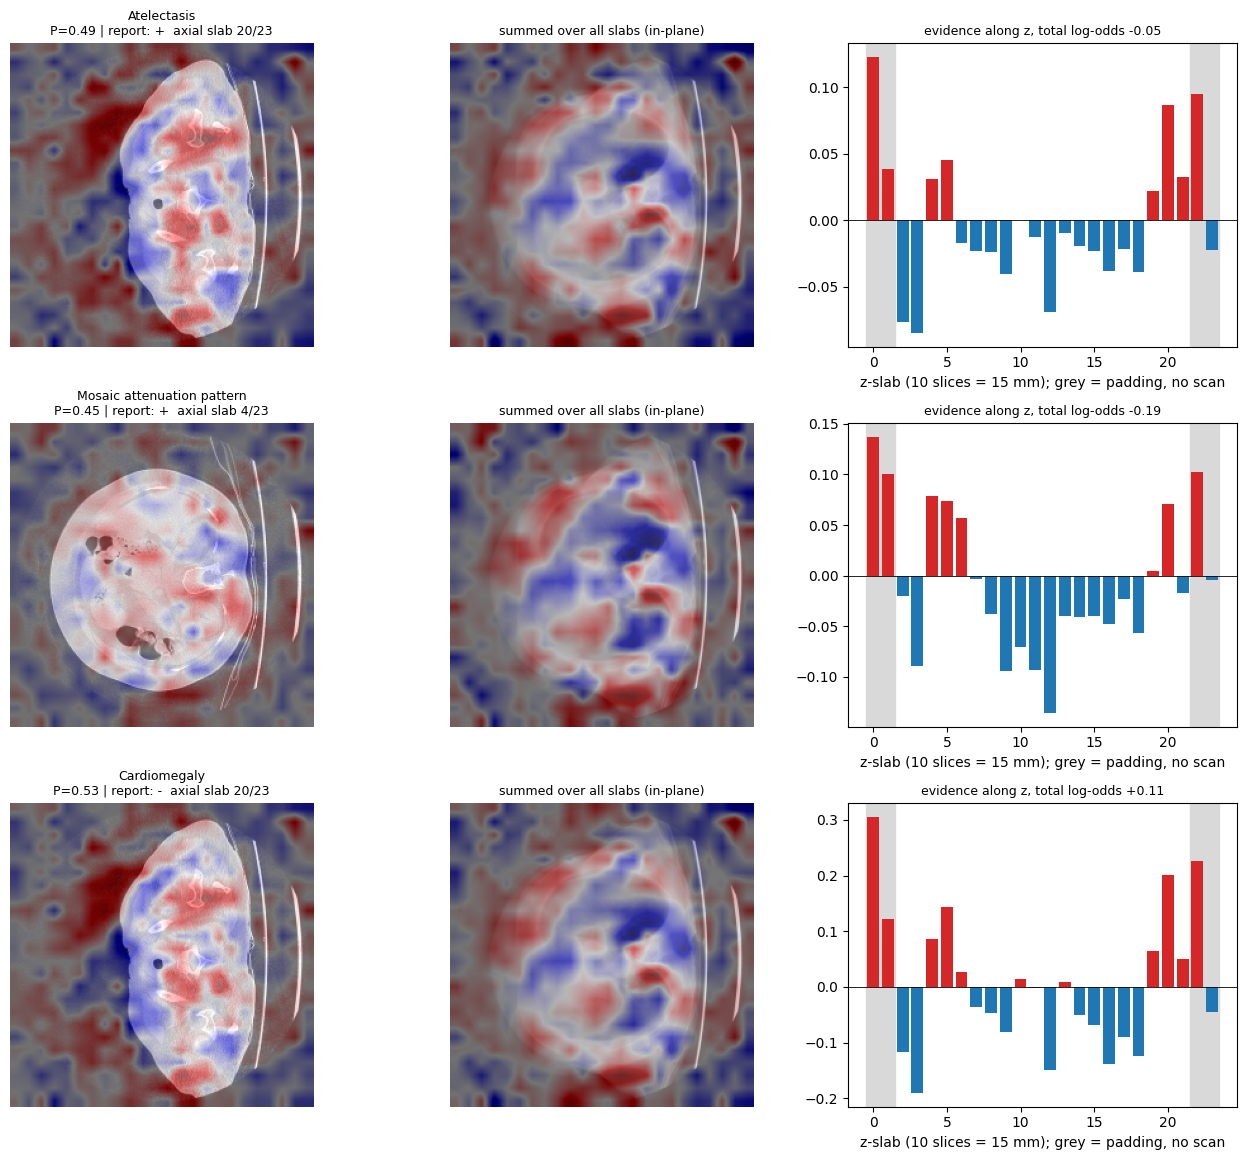

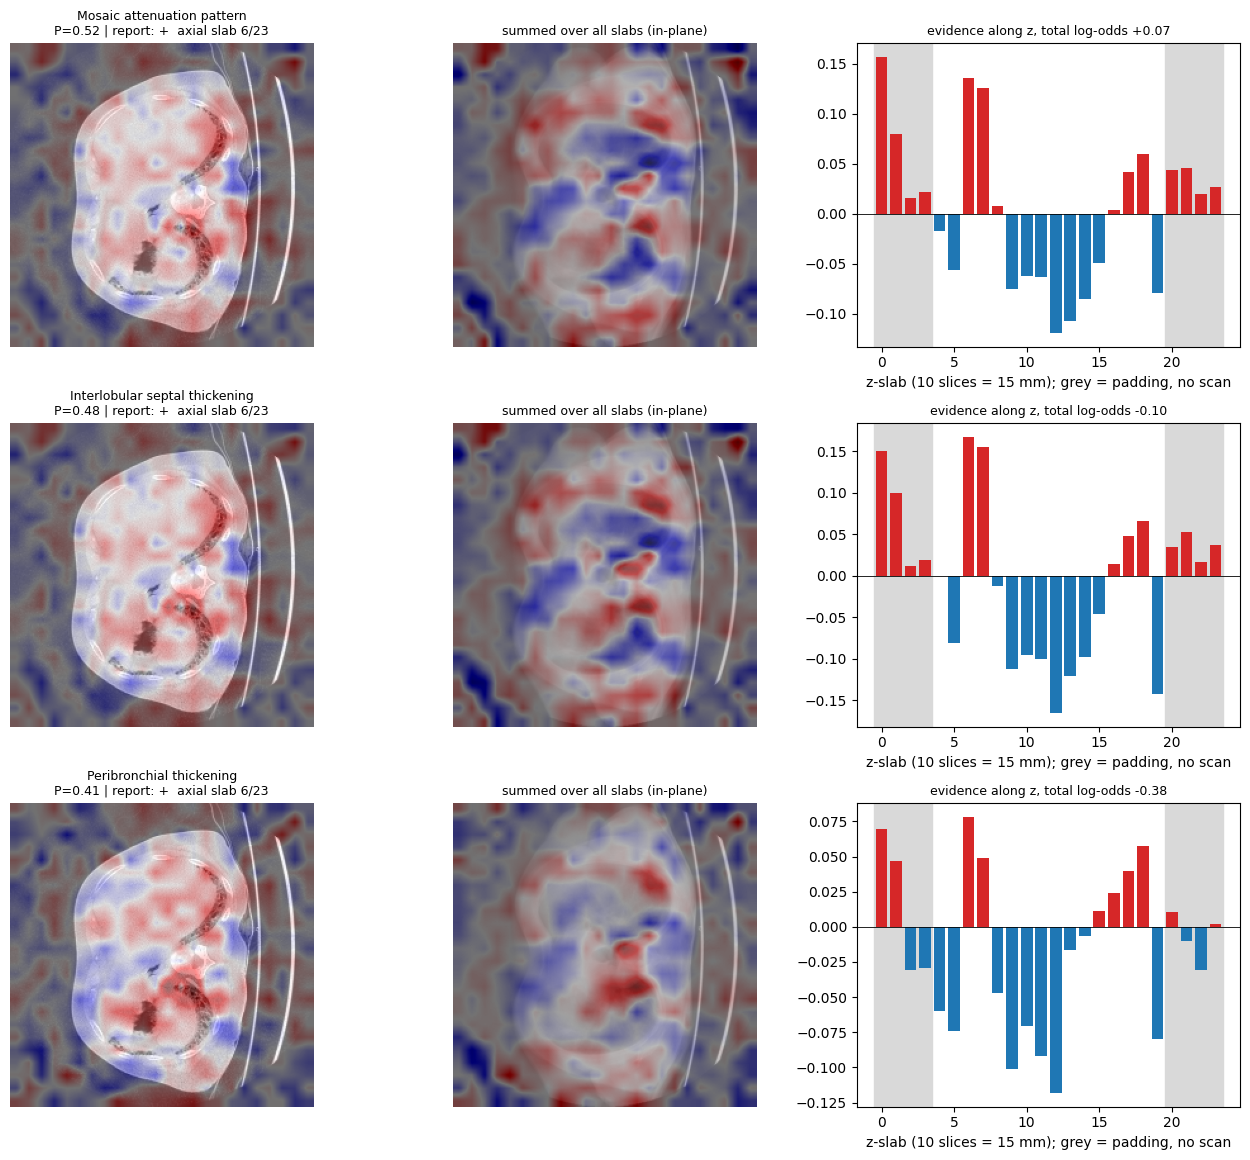

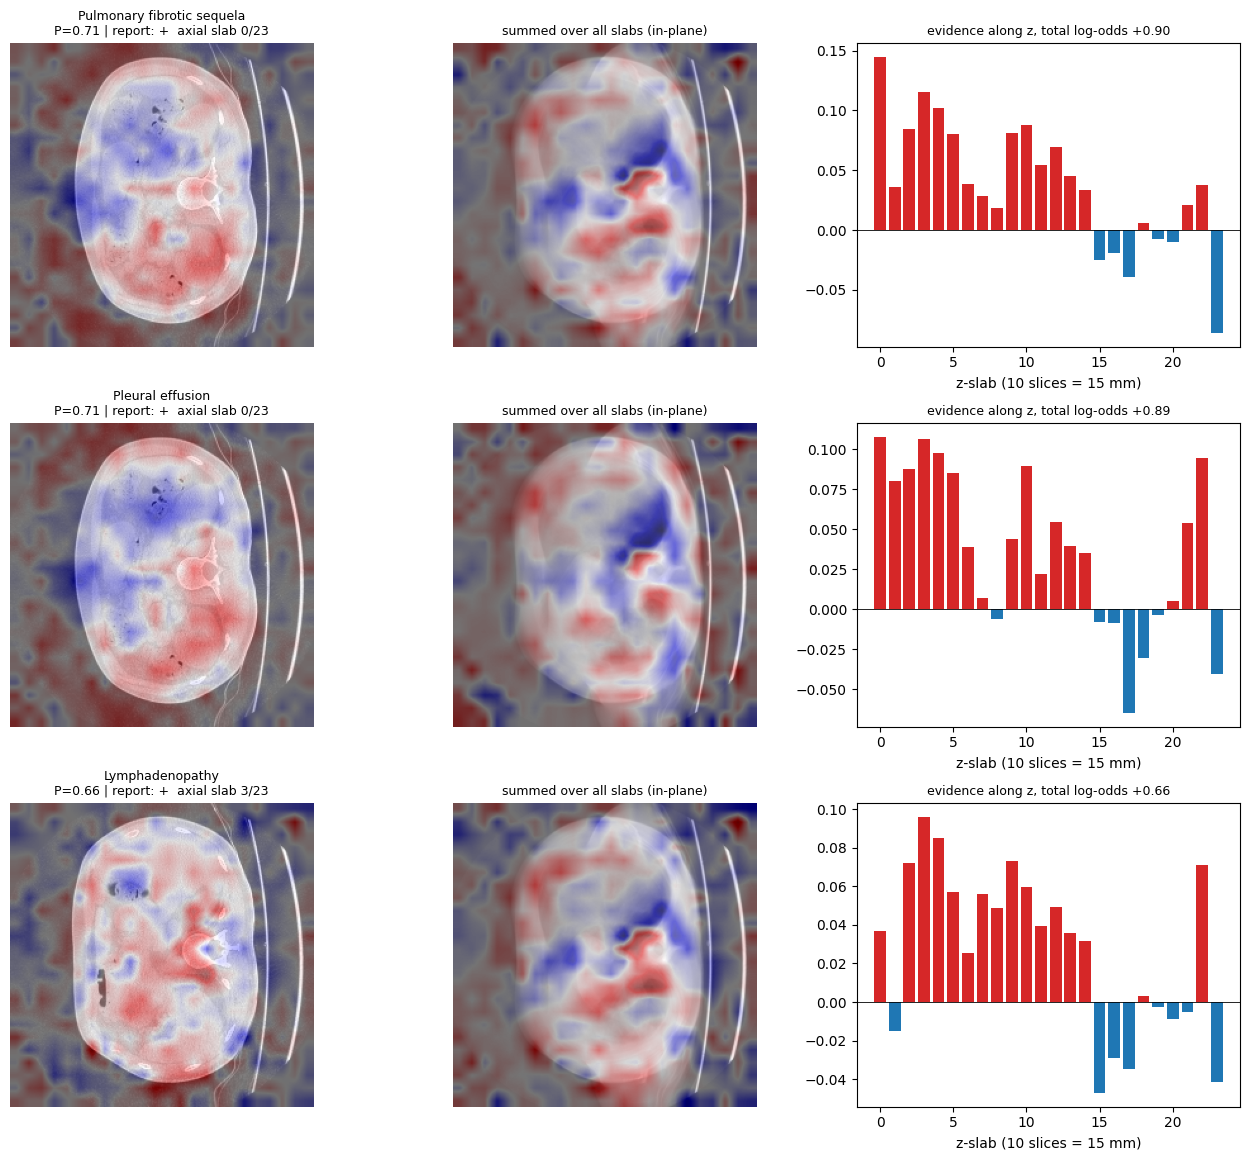

all evidence figures saved in /content/drive/MyDrive/NHRD - Local Sample/ctclip_test_outputs/figures | raw maps in /content/drive/MyDrive/NHRD - Local Sample/ctclip_test_outputs/evidence_maps


In [13]:
def evidence_figure(k, path=None):
    delta = MAPS[k]                                            # (18, T, h, w)
    bg = BG[k].astype(np.float32)                              # (240, 240, 240) = (z, y, x), values HU/1000
    prob = P.loc[k]
    truth = [p for p in PATHOLOGIES if k in Y.index and Y.loc[k, p]]
    order = sorted(truth, key=lambda p: -prob[p])[:3]
    order += [p for p in prob.sort_values(ascending=False).index if p not in order][: max(0, 3 - len(order))]
    T = delta.shape[1]
    has_scan = np.array([bg[t * 10:(t + 1) * 10].max() > -0.99 for t in range(T)])      # False for slabs that are pure padding (scan shorter than 240 x 1.5 mm)
    fig, axes = plt.subplots(len(order), 3, figsize=(13, 3.9 * len(order)), squeeze=False)
    for r, p in enumerate(order):
        m = delta[PATHOLOGIES.index(p)]
        vmax = np.percentile(np.abs(m), 99.5) + 1e-9
        t_star = int(np.argmax(np.where(has_scan, m.sum(axis=(1, 2)), -np.inf)))       # scanned slab with the most net evidence for 'present'
        z_star = min(t_star * 10 + 5, bg.shape[0] - 1)
        up = lambda a: F.interpolate(torch.from_numpy(a)[None, None], size=bg.shape[1:], mode="bilinear", align_corners=False)[0, 0].numpy()
        ax = axes[r, 0]
        ax.imshow(bg[z_star], cmap="gray", vmin=-1, vmax=0.4); ax.imshow(up(m[t_star]), cmap="seismic", vmin=-vmax, vmax=vmax, alpha=0.45)
        ax.set_title(f"{p}\nP={prob[p]:.2f} {'| report: +' if p in truth else '| report: -'}  axial slab {t_star}/{T - 1}", fontsize=9); ax.axis("off")
        ax = axes[r, 1]
        ax.imshow(bg.mean(axis=0), cmap="gray", vmin=-1, vmax=0.4); ax.imshow(up(m.sum(axis=0)), cmap="seismic", vmin=-np.abs(m.sum(0)).max() - 1e-9, vmax=np.abs(m.sum(0)).max() + 1e-9, alpha=0.45)
        ax.set_title("summed over all slabs (in-plane)", fontsize=9); ax.axis("off")
        ax = axes[r, 2]
        prof = m.sum(axis=(1, 2))
        cols = np.where(prof >= 0, "tab:red", "tab:blue")
        ax.bar(range(T), prof, color=cols, alpha=1.0); ax.axhline(0, color="k", lw=.6)
        for t in np.where(~has_scan)[0]:
            ax.axvspan(t - .5, t + .5, color="0.85", zorder=0)
        ax.set_title(f"evidence along z, total log-odds {prof.sum():+.2f}", fontsize=9)
        ax.set_xlabel("z-slab (10 slices = 15 mm)" + ("; grey = padding, no scan" if (~has_scan).any() else ""))
    plt.tight_layout()
    if path:
        plt.savefig(path, dpi=100)
    return fig

if MAPS:
    for i, k in enumerate(P.index):
        fig = evidence_figure(k, OUTPUT_DIR / "figures" / f"evidence_{k}.png")
        if i < EVIDENCE_INLINE_CASES:
            plt.show()
        else:
            plt.close(fig)
    print("all evidence figures saved in", OUTPUT_DIR / "figures", "| raw maps in", OUTPUT_DIR / "evidence_maps")
else:
    print("evidence maps were not computed (COMPUTE_EVIDENCE_MAPS = False)")

## 9b. Reference check on public CT-RATE validation scans
**Why.** Our scans give near-constant per-label probabilities and a low agreement with the report labels (sections 7-8). Two very different explanations are possible: the *model* has that calibration offset on any data, or something about *our data / preprocessing* creates it.
The public CT-RATE validation set separates them: same weights, same code path, public scans, and labels of the same kind as ours (RadBERT classifier output on the reports, `valid_predicted_labels.csv`).

**What this section does** (needs `HF_TOKEN` and accepted dataset terms; set `RUN_CTRATE = False` in section 1 to skip):
1. downloads the label / metadata tables and a stratified sample of `CTRATE_N_SCANS` scans from `valid_fixed` (one reconstruction per patient - the smallest one, typically 512 x 512 at 1.5 mm - non-chest scans excluded), about 100-350 MB each;
2. loads them like the official `data_inference_nii.py` (file array axes `(i, j, k)` -> `(k, i, j)`), **with one deliberate difference**: `valid_fixed` (CT-RATE v2) already stores Hounsfield units (its `data_correction_note.md` says the corrections are applied), so adding the metadata `RescaleIntercept` again, as the official script does, would shift everything by -1024 HU. We check the values (air must be near -1000) and only rescale if they are not HU;
3. scores them exactly like our scans, evaluates against their labels, and compares **per-label offsets local vs CT-RATE**;
4. checks whether **transferring CT-RATE's offsets / thresholds** to our scans helps;
5. compares **orientation**: which arrangement of our scans best matches what the model receives from CT-RATE volumes (header axis codes for CT-RATE files are `L, P, S`, i.e. the model's height axis points to the patient's left and its width axis to posterior);
6. compares scanner, kernel, field of view and coverage between CT-RATE metadata and our DICOM headers.

The sample is enriched for rarer labels (`CTRATE_MIN_POSITIVES`), so its *accuracy* is not comparable with the full validation set; per-label offsets, AUROC and the local-vs-CT-RATE comparison are.

In [14]:
CT_REPO = "ibrahimhamamci/CT-RATE"
CT = {"ok": False}                       # filled further down; the summary (section 10) reads it

def hf_fetch(rel):
    """One file of the gated dataset. Cached under CTRATE_DIR; hf_hub_download resumes interrupted transfers."""
    dst = CTRATE_DIR / rel
    if dst.exists() and dst.stat().st_size > 0:
        return dst
    from huggingface_hub import hf_hub_download
    return Path(hf_hub_download(repo_id=CT_REPO, repo_type="dataset", filename=rel, token=HF_TOKEN or None, local_dir=str(CTRATE_DIR)))

def ctrate_rel_path(name):
    m = re.match(r"valid_(\d+)_([a-z]+)_(\d+)\.nii\.gz$", name)
    return f"dataset/valid_fixed/valid_{m[1]}/valid_{m[1]}_{m[2]}/{name}"

_num = lambda s: (re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", str(s)) or ["nan"])[0]
CT_NAMES = []
if RUN_CTRATE:
    try:
        ct_labels = pd.read_csv(hf_fetch("dataset/multi_abnormality_labels/valid_predicted_labels.csv")).set_index("VolumeName")
        ct_meta = pd.read_csv(hf_fetch("dataset/metadata/validation_metadata.csv")).set_index("VolumeName")
        ct_nochest = set(re.findall(r"(valid_\d+_[a-z]+_\d+)\.nii\.gz", hf_fetch("dataset/metadata/no_chest_valid.txt").read_text()))
    except Exception as e:
        print("Could not fetch the CT-RATE label / metadata files:", repr(e)[:300])
        print("-> set HF_TOKEN (section 1) and accept the dataset terms on Hugging Face. Section 9b is skipped.")
        RUN_CTRATE = False

if RUN_CTRATE:
    CT_M = ct_meta.copy()                                        # metadata of ALL validation volumes (also used for the domain comparison)
    CT_M["xy"] = CT_M.XYSpacing.map(lambda s: float(_num(s)))
    CT_M["z"] = pd.to_numeric(CT_M.ZSpacing, errors="coerce")
    CT_M["fov"] = pd.to_numeric(CT_M.ReconstructionDiameter, errors="coerce")
    CT_M["zext"] = CT_M.NumberofSlices * CT_M.z
    CT_M["voxels"] = CT_M.Rows * CT_M.Columns * CT_M.NumberofSlices
    CT_M["zpad"] = 100 * (240 - (CT_M.zext / 1.5).fillna(0).astype(int)).clip(lower=0) / 240      # % of the 240 model slices that will be air padding
    CT_M["patient"] = CT_M.index.str.extract(r"valid_(\d+)_", expand=False)
    if CTRATE_VOLUMES:
        names = [n for n in CTRATE_VOLUMES if n in ct_labels.index and n in CT_M.index]
    else:
        stems = CT_M.index.str.replace(".nii.gz", "", regex=False)
        elig = CT_M[~stems.isin(ct_nochest) & CT_M.z.notna() & CT_M.xy.notna() & (CT_M.voxels <= CTRATE_MAX_VOXELS) & (CT_M.zext >= 150) & CT_M.index.isin(ct_labels.index)]
        pool = elig.sort_values("voxels").groupby("patient").head(1)          # one (smallest) reconstruction per patient
        order = list(np.random.default_rng(CTRATE_SEED).permutation(pool.index))
        lp = ct_labels.loc[order, PATHOLOGIES]
        chosen = []
        if CTRATE_MIN_POSITIVES:                                             # make sure every label has some positives, rarest labels first
            for lab in lp.sum().sort_values().index:
                while len(chosen) < CTRATE_N_SCANS and lp.loc[chosen, lab].sum() < CTRATE_MIN_POSITIVES:
                    cand = [n for n in order if n not in chosen and lp.loc[n, lab] == 1]
                    if not cand:
                        break
                    chosen.append(cand[0])
        chosen += [n for n in order if n not in chosen][: max(0, CTRATE_N_SCANS - len(chosen))]
        names = sorted(chosen[:CTRATE_N_SCANS])
    sel_lab = ct_labels.loc[names, PATHOLOGIES]
    print(f"{len(names)} CT-RATE validation scans selected of {len(ct_labels)} (one reconstruction per patient, non-chest excluded)")
    display(pd.DataFrame({"positives in selection": sel_lab.sum(), f"share of all {len(ct_labels)} valid volumes": ct_labels[PATHOLOGIES].mean().round(3)}).T)
    for i, name in enumerate(names, 1):
        try:
            with PROF.stage("ctrate_download", "ctrate", case=name):
                p = hf_fetch(ctrate_rel_path(name))
            CT_NAMES.append(name)
            print(f"[{i}/{len(names)}] {name}  {p.stat().st_size / 1e6:.0f} MB")
        except Exception as e:
            print(f"[{i}/{len(names)}] {name} skipped: {repr(e)[:160]}")
    if not CT_NAMES:
        print("No CT-RATE scan could be downloaded: section 9b is skipped.")

valid_predicted_labels.csv:   0%|          | 0.00/174k [00:00<?, ?B/s]

validation_metadata.csv:   0%|          | 0.00/948k [00:00<?, ?B/s]

no_chest_valid.txt:   0%|          | 0.00/1.83k [00:00<?, ?B/s]

24 CT-RATE validation scans selected of 3039 (one reconstruction per patient, non-chest excluded)


,Medical material,Arterial wall calcification,Cardiomegaly,Pericardial effusion,Coronary artery wall calcification,Hiatal hernia,Lymphadenopathy,Emphysema,Atelectasis,Lung nodule,Lung opacity,Pulmonary fibrotic sequela,Pleural effusion,Mosaic attenuation pattern,Peribronchial thickening,Consolidation,Bronchiectasis,Interlobular septal thickening
positives in selection,4.000,6.000,4.000,3.000,8.000,4.000,6.00,7.000,7.000,13.000,10.00,8.000,5.000,3.000,3.000,5.000,3.000,3.000
share of all 3039 valid volumes,0.103,0.285,0.107,0.074,0.252,0.137,0.26,0.197,0.235,0.448,0.39,0.273,0.124,0.083,0.117,0.191,0.109,0.082


...

dataset/valid_fixed/valid_928/valid_928_(…): downloading bytes:           |  0.00B            

[23/24] valid_928_a_2.nii.gz  109 MB


dataset/valid_fixed/valid_946/valid_946_(…): reconstructing file:   0%|          |  0.00B /  191MB            

dataset/valid_fixed/valid_946/valid_946_(…): downloading bytes:           |  0.00B            

[24/24] valid_946_a_1.nii.gz  191 MB


In [15]:
def read_ctrate_volume(name):
    """CT-RATE NIfTI -> float32 HU volume (k, i, j), the axis order the official loader hands to its resampling (transpose(2, 0, 1)).
    Verified against 50 real valid_fixed headers + 6 full pixel checks (Philips -1024 and Siemens -8192 DICOM-intercept conventions):
    header scl_slope/scl_inter are always (1, 0) - i.e. get_fdata() returns the stored ints unchanged - and real tissue is already
    calibrated HU. get_fdata() is used (not dataobj) for exact parity with the official data_inference_nii.py, which calls it directly."""
    import nibabel as nib
    nii = nib.load(str(CTRATE_DIR / ctrate_rel_path(name)))
    vol = nii.get_fdata().astype(np.float32)
    row = ct_meta.loc[name]
    # some scanners (seen: Siemens, RescaleIntercept -8192) pad the outside-of-reconstruction-circle corners with a sentinel far more
    # negative than real air, which can dominate a blind low percentile; check instead whether a real air/lung HU band is present at all
    frac_air = float(((vol > -1050) & (vol < -950)).mean())
    how = "already HU"
    if frac_air < 0.001:      # no plausible air HU anywhere -> raw stored values (CT-RATE v1 style), apply the DICOM rescale from the metadata table
        vol = vol * float(row.RescaleSlope) + float(row.RescaleIntercept)
        frac_air = float(((vol > -1050) & (vol < -950)).mean())
        how = f"rescaled with metadata ({row.RescaleSlope} x + {row.RescaleIntercept})"
    p_air = float(np.percentile(vol[::4, ::4, ::4], 0.5))
    xy, z = float(_num(row.XYSpacing)), float(row.ZSpacing)
    return vol.transpose(2, 0, 1), (z, xy, xy), dict(hu=how, air_p0_5=round(p_air), frac_real_air_voxels=round(frac_air, 4), shape=tuple(int(s) for s in nii.shape), spacing_zxy=(z, xy))

CT_PROBS, CT_SWAP, CT_FLIP, CT_COARSE, CT_INFO = {}, {}, {}, {}, {}
if RUN_CTRATE and CT_NAMES:
    ct_dev = DEVICES[0] if CTRATE_DEVICE == "auto" else CTRATE_DEVICE
    ct_run = f"ctrate_{ct_dev}"
    os.environ["CTCLIP_DEVICE"] = ct_dev
    with PROF.stage("model_to_device", ct_run, device=ct_dev):
        clip.to(ct_dev)
    with PROF.stage("text_encode", ct_run, device=ct_dev):
        txt_ct = encode_prompts(ct_dev)
    for i, name in enumerate(CT_NAMES, 1):
        print(f"[{ct_dev}] CT-RATE {name} ({i}/{len(CT_NAMES)}) ...", end=" ", flush=True)
        with PROF.stage("ctrate_read", ct_run, case=name):
            vol, sp, info = read_ctrate_volume(name)
        CT_INFO[name] = info
        with PROF.stage("preprocess", ct_run, case=name):
            vt = preprocess_volume(vol, sp)
        del vol
        with PROF.stage("to_device", ct_run, case=name, device=ct_dev):
            x = vt[None].to(ct_dev)
        with PROF.stage("image_encoder", ct_run, case=name, device=ct_dev):
            tokens = encode_image(x)
        with PROF.stage("projection_score", ct_run, case=name, device=ct_dev):
            CT_PROBS[name] = score_tokens(tokens, txt_ct)[0].float().cpu().numpy()
        CT_COARSE[name] = coarse_volume(vt)
        if ct_dev == "cuda":                                                   # orientation sensitivity on data where the official arrangement is right by definition
            with torch.no_grad():
                if SWEEP_INPLANE:
                    CT_SWAP[name] = score_tokens(encode_image(x.transpose(-1, -2).contiguous()), txt_ct)[0].float().cpu().numpy()
                if SWEEP_Z_FLIP:
                    CT_FLIP[name] = score_tokens(encode_image(torch.flip(x, dims=[2])), txt_ct)[0].float().cpu().numpy()
        t_scan = sum(r["seconds"] for r in PROF.records if r["run"] == ct_run and r["case"] == name and r["stage"] in ("ctrate_read", "preprocess", "to_device", "image_encoder", "projection_score"))
        print(f"{t_scan:.1f}s | {info['hu']} (air p0.5 = {info['air_p0_5']} HU)")
        del x, tokens, vt
        if ct_dev == "cuda":
            torch.cuda.empty_cache()

    P_ct = pd.DataFrame(CT_PROBS, index=PATHOLOGIES).T.rename_axis("volume")
    Y_ct = ct_labels.loc[CT_NAMES, PATHOLOGIES].astype(int)
    P_ct.to_csv(OUTPUT_DIR / "ctrate_probabilities.csv"); Y_ct.to_csv(OUTPUT_DIR / "ctrate_labels.csv")
    for tag, dd in (("inplane_alt", CT_SWAP), ("zflip", CT_FLIP)):
        if dd:
            pd.DataFrame(dd, index=PATHOLOGIES).T.rename_axis("volume").to_csv(OUTPUT_DIR / f"ctrate_probabilities_{tag}.csv")
    bad_hu = [n for n, v in CT_INFO.items() if v.get("frac_real_air_voxels", 1) < 0.001]
    if bad_hu:
        print("WARNING: these volumes show no plausible air HU even after the rescale check (non-chest? unusual protocol?):", bad_hu)
    (OUTPUT_DIR / "runs" / f"ctrate_{ct_dev}_{dt.datetime.now():%Y%m%d_%H%M%S}.json").write_text(json.dumps(
        dict(saved=dt.datetime.now().isoformat(timespec="seconds"), device=ct_dev, model_file=MODEL_FILE, dry_run=DRY_RUN_RANDOM_WEIGHTS, inplane_order=INPLANE_ORDER,
             hardware=HW, volumes=CT_NAMES, info={n: {k: (list(v) if isinstance(v, tuple) else v) for k, v in d.items()} for n, d in CT_INFO.items()},
             records=[r for r in PROF.records if r["run"] in ("ctrate", ct_run)], probs={n: v.tolist() for n, v in CT_PROBS.items()}), default=float, indent=1))
    tt = pd.DataFrame([r for r in PROF.records if r["run"] == ct_run]).groupby("stage").seconds.mean().round(2)
    print("\nmean seconds per CT-RATE scan by stage:", tt.to_dict())

[cuda] CT-RATE valid_1002_a_2.nii.gz (1/24) ... 6.4s | already HU (air p0.5 = -1024 HU)
[cuda] CT-RATE valid_1060_a_1.nii.gz (2/24) ... 5.8s | already HU (air p0.5 = -8192 HU)
[cuda] CT-RATE valid_1071_a_2.nii.gz (3/24) ... 6.4s | already HU (air p0.5 = -1024 HU)
[cuda] CT-RATE valid_1123_a_2.nii.gz (4/24) ... 4.9s | already HU (air p0.5 = -8192 HU)
[cuda] CT-RATE valid_1175_a_2.nii.gz (5/24) ... 3.4s | already HU (air p0.5 = -1027 HU)
[cuda] CT-RATE valid_1243_a_2.nii.gz (6/24) ... 4.4s | already HU (air p0.5 = -8192 HU)
[cuda] CT-RATE valid_1248_a_2.nii.gz (7/24) ... 7.7s | already HU (air p0.5 = -1024 HU)
[cuda] CT-RATE valid_1289_a_1.nii.gz (8/24) ... 4.8s | already HU (air p0.5 = -1024 HU)
[cuda] CT-RATE valid_166_a_2.nii.gz (9/24) ... 6.2s | already HU (air p0.5 = -1101 HU)
[cuda] CT-RATE valid_191_b_2.nii.gz (10/24) ... 5.7s | already HU (air p0.5 = -8192 HU)
[cuda] CT-RATE valid_279_a_2.nii.gz (11/24) ... 5.0s | already HU (air p0.5 = -8192 HU)
[cuda] CT-RATE valid_316_a_2.nii.

#### A. CT-RATE sample: 24 validation scans x 18 labels (threshold 0.5)

,CT-RATE
accuracy,0.581
accuracy_if_all_negative,0.764
micro_precision,0.329
micro_recall,0.745
micro_F1,0.456
micro_AUROC,0.657
micro_AP,0.348
mean_prob_on_positive_labels,0.602
mean_prob_on_negative_labels,0.480


,raw probability,prior-corrected (logit - label mean),label prior only (no image info)
pooled_AUROC,0.657,0.656,0.532
pooled_AP,0.348,0.353,0.246
mean_per_label_AUROC,0.671,0.671,0.500
labels_with_both_classes,18.000,18.000,18.000
mean_within_scan_AUROC,0.600,0.615,0.547


,support,pred_pos,TP,FP,FN,TN,precision,recall,F1,AUROC
label,,,,,,,,,,
Medical material,4,13,4,9,0,11,0.308,1.000,0.471,0.800
Arterial wall calcification,6,13,4,9,2,9,0.308,0.667,0.421,0.667
Cardiomegaly,4,13,4,9,0,11,0.308,1.000,0.471,0.912
Pericardial effusion,3,13,2,11,1,10,0.154,0.667,0.250,0.714
Coronary artery wall calcification,8,15,6,9,2,7,0.400,0.750,0.522,0.688
Hiatal hernia,4,15,3,12,1,8,0.200,0.750,0.316,0.525
Lymphadenopathy,6,13,4,9,2,9,0.308,0.667,0.421,0.611
Emphysema,7,16,6,10,1,7,0.375,0.857,0.522,0.639
Atelectasis,7,14,6,8,1,9,0.429,0.857,0.571,0.714


#### B. Label offsets: local scans vs CT-RATE scans (same model, same code)

,CT-RATE mean P,local mean P,CT-RATE scans >= thr,local scans >= thr,CT-RATE positives (sample),CT-RATE positives (all valid),local positives,logit shift (local - CT-RATE),CT-RATE AUROC,local AUROC
Bronchiectasis,0.54,0.44,0.62,0.43,0.12,0.11,0.43,-0.42,0.48,0.75
Hiatal hernia,0.53,0.47,0.62,0.43,0.17,0.14,0.00,-0.27,0.52,NaN
Lung nodule,0.53,0.43,0.54,0.29,0.54,0.45,0.29,-0.43,0.55,0.80
Emphysema,0.53,0.44,0.67,0.14,0.29,0.20,0.00,-0.36,0.64,NaN
Peribronchial thickening,0.52,0.48,0.58,0.43,0.12,0.12,0.29,-0.17,0.75,0.00
Coronary artery wall calcification,0.52,0.49,0.62,0.43,0.33,0.25,0.00,-0.13,0.69,NaN
Arterial wall calcification,0.52,0.47,0.54,0.43,0.25,0.29,0.00,-0.18,0.67,NaN
Atelectasis,0.51,0.46,0.58,0.14,0.29,0.23,0.29,-0.21,0.71,0.80
Lymphadenopathy,0.51,0.44,0.54,0.29,0.25,0.26,0.43,-0.31,0.61,0.58
Cardiomegaly,0.51,0.44,0.54,0.43,0.17,0.11,0.00,-0.31,0.91,NaN


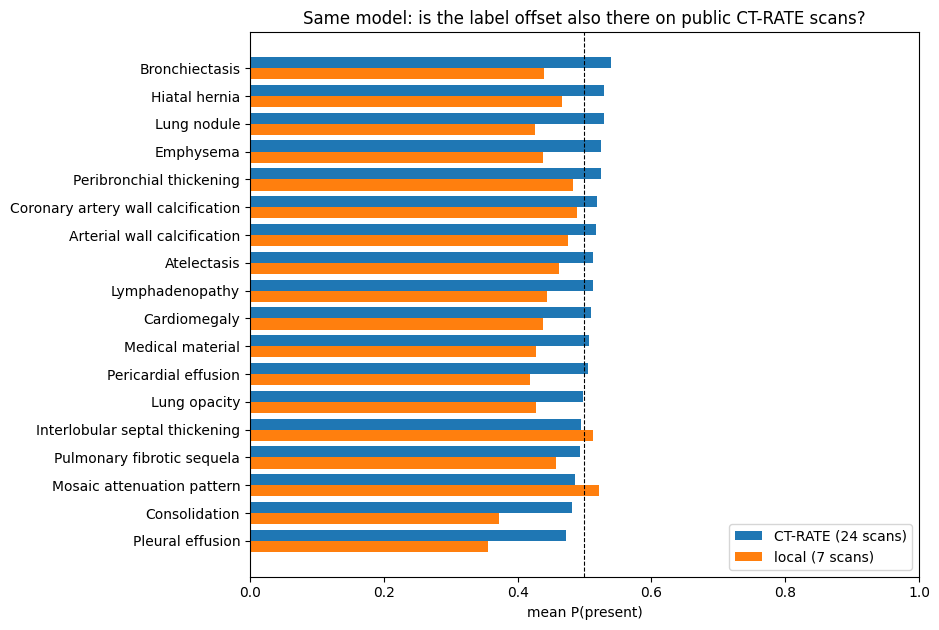

#### Labels that fire on every local scan although no local report mentions them

,note
0,no such label in this run


#### C. Does calibration learned on CT-RATE transfer to our scans?

,accuracy,precision,recall,F1,TP,FP,FN,TN
local @ fixed 0.5,0.627,0.214,0.391,0.277,9.0,33.0,14.0,70.0
local @ per-label thresholds from CT-RATE,0.627,0.125,0.174,0.145,4.0,28.0,19.0,75.0
"CT-RATE @ its own thresholds (in-sample, optimistic)",0.692,0.423,0.833,0.561,85.0,116.0,17.0,214.0


,"local, own label means","local, label means taken from CT-RATE"
pooled_AUROC,0.530,0.550
pooled_AP,0.258,0.262
mean_per_label_AUROC,0.577,0.577
labels_with_both_classes,11.000,11.000
mean_within_scan_AUROC,0.615,0.573


...

Current arrangement (identity, z as is) ranks 1 of 16 with mean correlation 0.698; best is 'identity', z as is (0.698).
-> our model input is arranged like the CT-RATE input. Good.


On CT-RATE itself (prior-corrected scores), does swapping h/w hurt? If yes, the model is orientation-sensitive on its own kind of data:

,official CT-RATE arrangement,h/w swapped
pooled_AUROC,0.656,0.473
pooled_AP,0.353,0.233
mean_per_label_AUROC,0.671,0.472
labels_with_both_classes,18.000,18.000
mean_within_scan_AUROC,0.615,0.498


#### E. How different are our scans from CT-RATE? (CT-RATE metadata table vs our DICOM headers)

,CT-RATE validation (n = 3039),our scans
property,,
Manufacturer,"Philips 63%, Siemens Healthineers 28%, PNMS 5%...",TOSHIBA
Convolution kernel,"B 28%, YA 26%, ['Br40f', '3'] 14%, ['Br60f', '...",FC81 -> 0.0% of CT-RATE scans share it
Patient position,"HFS 100%, FFS 0%",FFS
Reconstruction FOV (mm),368.0 (5-95%: 311.8-444.0),296-390 (percentile of each scan in CT-RATE:...
In-plane pixel spacing (mm),0.7 (5-95%: 0.3-0.8),"0.58-0.76 (percentiles: 4203: 50, 4213: 81, ..."
Air padding of the 240-slice input (%),5.8 (5-95%: 0.0-24.2),"4-38 (percentiles: 4203: 89, 4213: 99, 4214:..."


In [16]:
if RUN_CTRATE and CT_PROBS and len(common):
    n_ct = len(P_ct)
    per_ct, overall_ct, _ = evaluate(P_ct, Y_ct, THRESHOLD)
    PC_ct = {"raw probability": threshold_free_metrics(P_ct, Y_ct),
             "prior-corrected (logit - label mean)": threshold_free_metrics(prior_correct(P_ct), Y_ct),
             "label prior only (no image info)": threshold_free_metrics(prior_only(P_ct), Y_ct)}
    display(Markdown(f"#### A. CT-RATE sample: {n_ct} validation scans x 18 labels (threshold {THRESHOLD})"))
    display(pd.DataFrame({"CT-RATE": {k: overall_ct[k] for k in ["accuracy", "accuracy_if_all_negative", "micro_precision", "micro_recall", "micro_F1", "micro_AUROC", "micro_AP",
                                                                "mean_prob_on_positive_labels", "mean_prob_on_negative_labels"]}}).round(3))
    display(pd.DataFrame(PC_ct).round(3))
    display(per_ct.round(3))
    per_ct.round(4).to_csv(OUTPUT_DIR / "ctrate_per_label_metrics.csv")

    # ---- B. label offsets: local vs CT-RATE ------------------------------------------------------------------------------
    lg = lambda S: pd.DataFrame(_logit(S.to_numpy()), index=S.index, columns=S.columns)
    Pl, Yl = P.loc[common], Y.loc[common]
    CMP_LM = pd.DataFrame({
        "CT-RATE mean P": P_ct.mean(), "local mean P": Pl.mean(),
        "CT-RATE scans >= thr": (P_ct >= THRESHOLD).mean(), "local scans >= thr": (Pl >= THRESHOLD).mean(),
        "CT-RATE positives (sample)": Y_ct.mean(), "CT-RATE positives (all valid)": ct_labels[PATHOLOGIES].mean(), "local positives": Yl.mean(),
        "logit shift (local - CT-RATE)": lg(Pl).mean() - lg(P_ct).mean(),
        "CT-RATE AUROC": pd.Series({p: auroc(Y_ct[p], P_ct[p]) for p in PATHOLOGIES}), "local AUROC": pd.Series({p: auroc(Yl[p], Pl[p]) for p in PATHOLOGIES})})
    CMP_LM = CMP_LM.sort_values("CT-RATE mean P", ascending=False)
    display(Markdown("#### B. Label offsets: local scans vs CT-RATE scans (same model, same code)"))
    display(CMP_LM.round(2))
    CMP_LM.round(4).to_csv(OUTPUT_DIR / "ctrate_vs_local_label_offsets.csv")
    fig, ax = plt.subplots(figsize=(9.5, 6.4))
    yy = np.arange(len(CMP_LM))
    ax.barh(yy - 0.2, CMP_LM["CT-RATE mean P"], 0.4, label=f"CT-RATE ({n_ct} scans)"); ax.barh(yy + 0.2, CMP_LM["local mean P"], 0.4, label=f"local ({len(Pl)} scans)")
    ax.axvline(THRESHOLD, color="k", lw=.8, ls="--"); ax.set_yticks(yy); ax.set_yticklabels(CMP_LM.index); ax.invert_yaxis(); ax.set_xlabel("mean P(present)"); ax.set_xlim(0, 1); ax.legend(loc="lower right")
    ax.set_title("Same model: is the label offset also there on public CT-RATE scans?"); plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "figures" / "ctrate_vs_local_label_offsets.png", dpi=110); plt.show()

    # the labels that fire on every local scan although no local report mentions them
    hi = [p for p in PATHOLOGIES if (Pl[p] >= THRESHOLD).all() and Yl[p].sum() == 0]
    fpr = lambda p: float((P_ct[p][Y_ct[p] == 0] >= THRESHOLD).mean()) if (Y_ct[p] == 0).any() else np.nan
    tbl = pd.DataFrame({"local: scans >= thr (all report-negative)": {p: float((Pl[p] >= THRESHOLD).mean()) for p in hi},
                        "CT-RATE: report-negative scans >= thr": {p: fpr(p) for p in hi},
                        "CT-RATE: mean P (report-negative)": {p: float(P_ct[p][Y_ct[p] == 0].mean()) for p in hi},
                        "CT-RATE: mean P (report-positive)": {p: float(P_ct[p][Y_ct[p] == 1].mean()) if (Y_ct[p] == 1).any() else np.nan for p in hi},
                        "CT-RATE n neg / pos": {p: f"{int((Y_ct[p] == 0).sum())} / {int((Y_ct[p] == 1).sum())}" for p in hi}})
    verdicts = []
    for p in hi:
        f, n_neg = fpr(p), int((Y_ct[p] == 0).sum())
        if np.isnan(f):
            continue
        if n_neg < 8:
            verdicts.append(f"- **{p}**: only {n_neg} report-negative CT-RATE scans, too few to say whether the offset is also present on public data (raise CTRATE_N_SCANS).")
            continue
        verdicts.append(f"- **{p}**: fires on {100 * f:.0f}% of the {int((Y_ct[p] == 0).sum())} report-negative CT-RATE scans (local: 100%) -> " +
                        ("the offset is also present on public data: a property of the model / prompts" if f >= 0.5 else
                         "much lower on public data: points to something specific to our scans or preprocessing" if f < 0.25 else "in between: partly model, partly data"))
    display(Markdown("#### Labels that fire on every local scan although no local report mentions them"))
    display(tbl.round(2) if len(hi) else pd.DataFrame({"note": ["no such label in this run"]}))
    display(Markdown("\n".join(verdicts)))

    # ---- C. do CT-RATE's offsets / thresholds transfer to our scans? --------------------------------------------------------
    def youden(y, s):
        y, s = np.asarray(y), np.asarray(s, float)
        if (y == 1).sum() < 2 or (y == 0).sum() < 2:
            return np.nan
        best, bt = -1.0, np.nan
        for t in np.unique(s):
            pr = s >= t
            j = pr[y == 1].mean() - pr[y == 0].mean()
            if j > best:
                best, bt = j, t
        return bt
    thr_ct = pd.Series({p: youden(Y_ct[p], P_ct[p]) for p in PATHOLOGIES}).fillna(THRESHOLD)
    def pooled_at(Pm, Ym, thr):
        B = Pm.ge(thr, axis=1).to_numpy(); yb = Ym.to_numpy().astype(bool)
        tp, fp_, fn_, tn_ = int((B & yb).sum()), int((B & ~yb).sum()), int((~B & yb).sum()), int((~B & ~yb).sum())
        pr, rc, f1_ = prf(tp, fp_, fn_)
        return dict(accuracy=(tp + tn_) / yb.size, precision=pr, recall=rc, F1=f1_, TP=tp, FP=fp_, FN=fn_, TN=tn_)
    TR = pd.DataFrame({f"local @ fixed {THRESHOLD}": pooled_at(Pl, Yl, pd.Series(THRESHOLD, index=PATHOLOGIES)),
                       "local @ per-label thresholds from CT-RATE": pooled_at(Pl, Yl, thr_ct),
                       "CT-RATE @ its own thresholds (in-sample, optimistic)": pooled_at(P_ct, Y_ct, thr_ct)}).T
    shifted = pd.DataFrame(lg(Pl).to_numpy() - lg(P_ct).mean().to_numpy(), index=Pl.index, columns=Pl.columns)
    TF = pd.DataFrame({"local, own label means": threshold_free_metrics(prior_correct(Pl), Yl),
                       "local, label means taken from CT-RATE": threshold_free_metrics(shifted, Yl)})
    display(Markdown("#### C. Does calibration learned on CT-RATE transfer to our scans?"))
    display(TR.round(3)); display(TF.round(3))
    print("Per-label thresholds use the Youden index on CT-RATE (only for labels with >= 2 positive and 2 negative CT-RATE scans; others keep the fixed threshold). "
          f"With {n_ct} CT-RATE scans these thresholds are noisy: read this as 'does the offset carry over', not as a calibrated model.")
    TR.round(4).to_csv(OUTPUT_DIR / "ctrate_threshold_transfer.csv"); TF.round(4).to_csv(OUTPUT_DIR / "ctrate_offset_transfer.csv")

    # ---- D. orientation: which arrangement of our scans best matches what CT-RATE volumes look like to the model ----------------
    def dihedral(a, i):
        a = a[:, :, ::-1] if i >= 4 else a
        return np.rot90(a, i % 4, axes=(1, 2))
    _pr = np.arange(24.0).reshape(2, 3, 4)
    dnames = {i: ("identity" if i == 0 else "swap h/w (transpose)" if np.array_equal(dihedral(_pr, i), _pr.transpose(0, 2, 1)) else f"in-plane rotation/mirror #{i}") for i in range(8)}
    def _corr(a, b):
        a, b = np.clip(a, -1, 0.4).ravel(), np.clip(b, -1, 0.4).ravel()
        a, b = a - a.mean(), b - b.mean()
        return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))
    ct_mean = np.mean(list(CT_COARSE.values()), axis=0)
    rows_o = []
    for i in range(8):
        for zf in (False, True):
            cs = [_corr((dihedral(c, i)[::-1] if zf else dihedral(c, i)), ct_mean) for c in COARSE_LOCAL.values()]
            rows_o.append(dict(transform_applied_to_our_model_input=dnames[i], z_order="reversed" if zf else "as is", mean_corr=np.mean(cs), min_corr=np.min(cs), max_corr=np.max(cs)))
    ORI = pd.DataFrame(rows_o).sort_values("mean_corr", ascending=False).reset_index(drop=True)
    cur = ORI[(ORI.transform_applied_to_our_model_input == "identity") & (ORI.z_order == "as is")].index[0]
    display(Markdown(f"#### D. Orientation of our model input vs CT-RATE model input (`INPLANE_ORDER = '{INPLANE_ORDER}'`)"))
    display(ORI.head(6).round(3))
    print(f"Current arrangement (identity, z as is) ranks {cur + 1} of {len(ORI)} with mean correlation {ORI.loc[cur, 'mean_corr']:.3f}; best is "
          f"'{ORI.loc[0, 'transform_applied_to_our_model_input']}', z {ORI.loc[0, 'z_order']} ({ORI.loc[0, 'mean_corr']:.3f}).")
    if cur == 0:
        print("-> our model input is arranged like the CT-RATE input. Good.")
    else:
        print("-> our model input is NOT arranged like CT-RATE input: apply the best transform (INPLANE_ORDER / Z_ORDER in section 1) and re-run.")
    ORI.round(4).to_csv(OUTPUT_DIR / "orientation_check.csv", index=False)
    if CT_SWAP:
        Ps_ct = pd.DataFrame(CT_SWAP, index=PATHOLOGIES).T
        _o = pd.DataFrame({"official CT-RATE arrangement": threshold_free_metrics(prior_correct(P_ct), Y_ct), "h/w swapped": threshold_free_metrics(prior_correct(Ps_ct.loc[P_ct.index]), Y_ct)})
        display(Markdown("On CT-RATE itself (prior-corrected scores), does swapping h/w hurt? If yes, the model is orientation-sensitive on its own kind of data:"))
        display(_o.round(3))

    # ---- E. scanner / protocol / coverage: CT-RATE metadata vs our DICOM headers ---------------------------------------------
    loc_rows = []
    for r in cases.itertuples():
        d0 = pydicom.dcmread(str(next(Path(r.path).rglob("*.dcm"))), stop_before_pixels=True)
        z_sp = SPACINGS.get(r.key, (np.nan,) * 3)[0]; n_sl = CASE_INFO.get(r.key, {}).get("n_slices", np.nan)
        zr = int(n_sl * z_sp / 1.5) if n_sl == n_sl else np.nan
        loc_rows.append(dict(case=r.key, manufacturer=str(d0.get("Manufacturer")), kernel=str(d0.get("ConvolutionKernel")), position=str(d0.get("PatientPosition")),
                             fov=float(d0.get("ReconstructionDiameter", np.nan)), xy=float(d0.PixelSpacing[0]), zpad=100 * max(240 - zr, 0) / 240 if zr == zr else np.nan))
    LOC = pd.DataFrame(loc_rows).set_index("case")
    top = lambda s, n=4: ", ".join(f"{k} {100 * v:.0f}%" for k, v in s.astype(str).value_counts(normalize=True).head(n).items())
    q = lambda s: f"{s.quantile(.5):.1f} (5-95%: {s.quantile(.05):.1f}-{s.quantile(.95):.1f})"
    pct = lambda col: ", ".join(f"{k}: {100 * (CT_M[col] < v).mean():.0f}" for k, v in LOC[col].items())
    DOM = pd.DataFrame([
        ("Manufacturer", top(CT_M.Manufacturer), ", ".join(sorted(set(LOC.manufacturer)))),
        ("Convolution kernel", top(CT_M.ConvolutionKernel, 5), ", ".join(sorted(set(LOC.kernel))) + f"  -> {100 * CT_M.ConvolutionKernel.astype(str).isin(set(LOC.kernel)).mean():.1f}% of CT-RATE scans share it"),
        ("Patient position", top(CT_M.PatientPosition), ", ".join(sorted(set(LOC.position)))),
        ("Reconstruction FOV (mm)", q(CT_M.fov), f"{LOC.fov.min():.0f}-{LOC.fov.max():.0f}   (percentile of each scan in CT-RATE: {pct('fov')})"),
        ("In-plane pixel spacing (mm)", q(CT_M.xy), f"{LOC.xy.min():.2f}-{LOC.xy.max():.2f}   (percentiles: {pct('xy')})"),
        ("Air padding of the 240-slice input (%)", q(CT_M.zpad), f"{LOC.zpad.min():.0f}-{LOC.zpad.max():.0f}   (percentiles: {pct('zpad')})"),
    ], columns=["property", f"CT-RATE validation (n = {len(CT_M)})", "our scans"]).set_index("property")
    display(Markdown("#### E. How different are our scans from CT-RATE? (CT-RATE metadata table vs our DICOM headers)"))
    display(DOM)
    DOM.to_csv(OUTPUT_DIR / "ctrate_domain_comparison.csv")

    # ---- results for the summary ---------------------------------------------------------------------------------------------
    CT = dict(ok=True, n=n_ct, device=ct_dev, overall=overall_ct, PC=PC_ct, compare=CMP_LM, transfer=TR, transfer_tf=TF, orientation=ORI, orientation_rank=int(cur + 1),
              domain=DOM, verdicts=verdicts, hu_counts=pd.Series([v["hu"].split(" (")[0] for v in CT_INFO.values()]).value_counts().to_dict())
    CT["lines"] = ([f"- CT-RATE reference ({n_ct} public validation scans, same pipeline): pooled AUROC raw {PC_ct['raw probability']['pooled_AUROC']:.2f}, prior-corrected "
                    f"{PC_ct['prior-corrected (logit - label mean)']['pooled_AUROC']:.2f}; accuracy at {THRESHOLD} = {overall_ct['accuracy']:.2f} (all-negative baseline {overall_ct['accuracy_if_all_negative']:.2f})."] + verdicts +
                   [f"- Orientation: our model input ranks {cur + 1} of {len(ORI)} against CT-RATE volumes (best: {ORI.loc[0, 'transform_applied_to_our_model_input']}, z {ORI.loc[0, 'z_order']})."])
elif RUN_CTRATE:
    print("Section 9b: nothing to evaluate (no CT-RATE scan was scored, or no local scan has labels).")

## 10. Summary of all tests
Built from the JSON files saved by each run in `ctclip_test_outputs/runs/` (latest run per device), so a GPU session and a separate CPU-only session appear together.

**Reading the memory numbers.** Host RAM is the peak resident set size of this Python process. A CPU run that follows a GPU run *in the same session* also carries memory still held from the earlier run (allocator caches, staged data), so it can read higher than reality — for the cleanest CPU figure, rerun the notebook on a CPU-only runtime. `process_peak_rss_gb` is the whole-process high-water mark when the run was saved.

### Test summary  
_model: CT-CLIP_v2.pt_

**Totals per run**  (each run over its *own* scans, so do not compare devices here - see the shared-scan table below; `first_scan_s` includes CUDA warm-up; `total_run_s` = one-time setup + all scans)

,cases,hw,one_time_setup_s,first_scan_s,later_scans_mean_s,mean_per_scan_s,all_scans_s,total_run_s,peak_ram_gb,process_peak_rss_gb,peak_vram_gb
run,,,,,,,,,,,
cpu,2,Intel(R) Xeon(R) CPU @ 2.00GHz (2 threads),167.44,32.11,25.16,28.64,57.27,224.71,5.94,5.95,NaN
cuda,7,Tesla T4,169.35,29.98,16.97,18.83,131.80,301.15,4.41,4.41,3.79


**CPU vs GPU on the 2 scan(s) every run has in common** (4203, 4213) - the fair comparison. `model_stages_s` = to_device + image_encoder + projection_score. DICOM decoding and preprocessing are the same CPU work in both runs, so differences there are I/O and run-to-run noise, not device speed.

,shared_scans,model_stages_s,image_encoder_s,dicom_read_plus_preprocess_s,end_to_end_s
run,,,,,
cpu,2,21.85,21.79,6.78,28.64
cuda,2,0.89,0.79,15.48,16.38


**Per-scan stages** (mean / min / max over scans; RAM = peak process RSS; VRAM = peak allocated incl. resident weights; working = peak − resident)

mean_s   min_s   max_s  peak_ram_gb  peak_vram_gb  \
run  stage                                                                 
cpu  dicom_read         5.391   1.204   9.578        4.461           NaN   
     preprocess         1.393   1.131   1.654        5.123           NaN   
     to_device          0.000   0.000   0.000        4.052           NaN   
     image_encoder     21.785  20.811  22.760        5.940           NaN   
     projection_score   0.067   0.063   0.071        4.103           NaN   
cuda dicom_read        16.358   1.214  42.118        2.841           NaN   
     preprocess         1.809   0.863   3.603        3.926           NaN   
     to_device          0.056   0.049   0.084        2.408         1.869   
     image_encoder      0.581   0.479   1.075        2.408         3.793   
     projection_score   0.013   0.003   0.074        2.408         1.896   
     evidence_maps      0.011   0.004   0.051        2.408         1.938   

                       vram_working_gb  
run  stage                              
cpu  dicom_read                    NaN  
     preprocess                    NaN  
     to_device                     NaN  
     image_encoder                 NaN  
     projection_score              NaN  
cuda dicom_read                    NaN  
     preprocess                    NaN  
     to_device                   0.206  
     image_encoder               1.927  
     projection_score            0.001  
     evidence_maps               0.043

**One-time costs**

seconds  peak_ram_gb  peak_vram_gb
run  stage                                               
cpu  data_stage_in     115.576        0.927           NaN
     model_build        22.761        2.431           NaN
     weights_download   22.066        3.937           NaN
     weights_load        6.149        4.410           NaN
     model_to_device     0.005        3.766           NaN
     text_encode         0.882        3.792           NaN
cuda data_stage_in     115.576        0.927           NaN
     model_build        22.761        2.431           NaN
     weights_download   22.066        3.937           NaN
     weights_load        6.149        4.410           NaN
     model_to_device     1.356        3.285         1.650
     text_encode         1.441        1.792         1.673

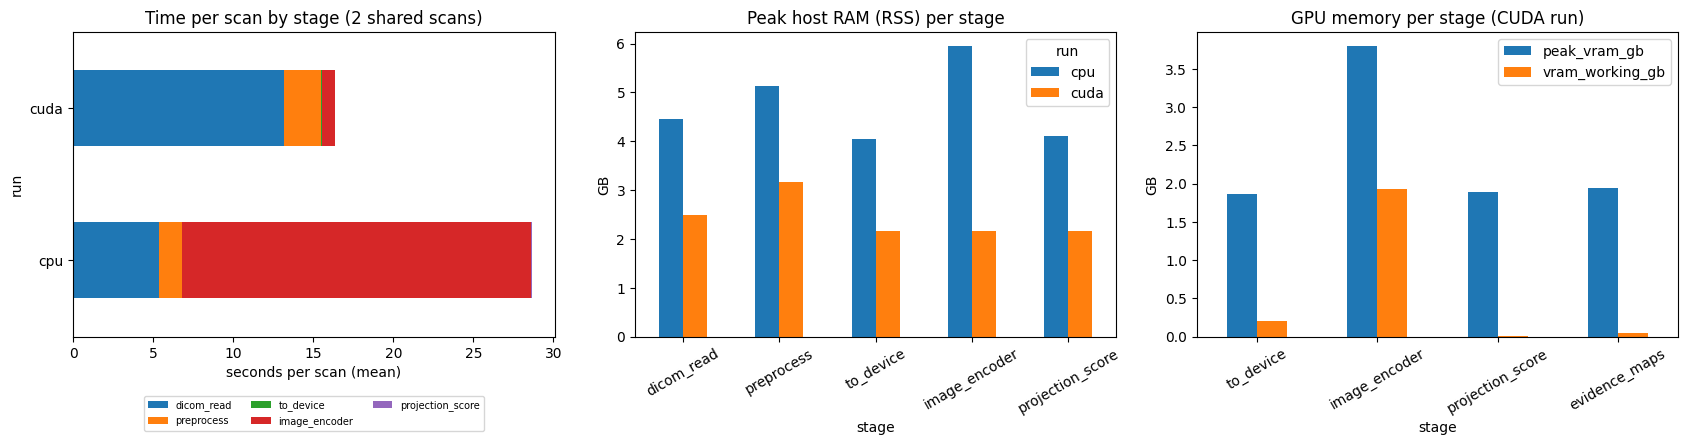

**Checklist**

,result
test,
1. DICOM input,7/7 cases read & converted (Implicit VR Little...
2. 18-label output,yes - probability of 'present' for each of the...
3. Evidence maps (official),NO - the released model returns only volume-le...
3b. Evidence maps (derived by us),"yes, experimental log-odds token maps; sums ma..."
4. Time / RAM / VRAM per stage,recorded for every stage and run (tables above...
5. CPU-only run,yes - 28.6 s per scan on Intel(R) Xeon(R) CPU ...
Scoring == official forward(),max |dP| = 6.0e-08
CPU == GPU predictions,max |dP| = 3.6e-07 (scans both runs share)
Checkpoint matches architecture,"missing keys 0, unexpected 0"


**Agreement with report-derived labels** (7 cases x 18 labels, cuda, threshold 0.5) - anecdotal sample size

,value
accuracy,0.627
accuracy_if_all_negative,0.817
micro_precision,0.214
micro_recall,0.391
micro_F1,0.277
micro_AUROC,0.557
micro_AP,0.269
mean_prob_on_positive_labels,0.470
mean_prob_on_negative_labels,0.442


**Threshold-free view, raw vs prior-corrected** (section 8b)

...

**Public CT-RATE reference** (24 validation scans, same pipeline, cuda; the sample is enriched for rarer labels, so compare offsets and AUROC, not accuracy)

,raw probability,prior-corrected (logit - label mean),label prior only (no image info)
pooled_AUROC,0.657,0.656,0.532
pooled_AP,0.348,0.353,0.246
mean_per_label_AUROC,0.671,0.671,0.500
labels_with_both_classes,18.000,18.000,18.000
mean_within_scan_AUROC,0.600,0.615,0.547


,CT-RATE mean P,local mean P,CT-RATE scans >= thr,local scans >= thr,logit shift (local - CT-RATE)
Bronchiectasis,0.54,0.44,0.62,0.43,-0.42
Hiatal hernia,0.53,0.47,0.62,0.43,-0.27
Lung nodule,0.53,0.43,0.54,0.29,-0.43
Emphysema,0.53,0.44,0.67,0.14,-0.36
Peribronchial thickening,0.52,0.48,0.58,0.43,-0.17
Coronary artery wall calcification,0.52,0.49,0.62,0.43,-0.13
Arterial wall calcification,0.52,0.47,0.54,0.43,-0.18
Atelectasis,0.51,0.46,0.58,0.14,-0.21
Lymphadenopathy,0.51,0.44,0.54,0.29,-0.31
Cardiomegaly,0.51,0.44,0.54,0.43,-0.31


**Findings**

- **CPU** (Intel(R) Xeon(R) CPU @ 2.00GHz (2 threads)): 28.6 s per scan mean over its 2 scan(s) (first scan 32.1 s), one-time setup 167 s, peak host RAM 5.9 GB.
- **CUDA** (Tesla T4): 18.8 s per scan mean over its 7 scan(s) (first scan 30.0 s), one-time setup 169 s, peak host RAM 4.4 GB, peak VRAM 3.8 GB.
- CPU vs GPU on the 2 shared scan(s): model stages 21.9 s vs 0.89 s (24x slower on CPU), image encoder alone 21.8 s vs 0.79 s. DICOM read + preprocessing is CPU work in both runs (6.8 s vs 15.5 s, so differences are I/O noise); end to end 28.6 s vs 16.4 s per scan.
- Slowest per-scan stage on CPU: `image_encoder` (21.8 s).
- Slowest per-scan stage on CUDA: `dicom_read` (16.4 s).
- 0.56 GB of the fp32 checkpoint (`*_extra` projections) is never used at inference.
- Evidence maps: not provided by CT-CLIP; only the derived, coarse, unvalidated log-odds maps above.
- CT-RATE reference (24 public validation scans, same pipeline): pooled AUROC raw 0.66, prior-corrected 0.66; accuracy at 0.5 = 0.58 (all-negative baseline 0.76).
- Orientation: our model input ranks 1 of 16 against CT-RATE volumes (best: identity, z as is).

summary written to /content/drive/MyDrive/NHRD - Local Sample/ctclip_test_outputs/summary.md


In [17]:
run_files = sorted((OUTPUT_DIR / "runs").glob("run_*.json"))
runs = {}
for f in run_files:
    j = json.loads(f.read_text())
    if j["model_file"] == MODEL_FILE:
        runs[j["device"]] = j                                   # later files overwrite earlier ones -> latest per device
CASE_STAGES = ["dicom_read", "preprocess", "to_device", "image_encoder", "projection_score", "evidence_maps"]
ONE_TIME = ["data_stage_in", "model_build", "weights_download", "weights_load", "model_to_device", "text_encode"]

def run_frames(j):
    df = pd.DataFrame(j["records"])
    df["source"] = np.where(df["run"] == "setup", "shared setup", "device")
    return df

rows_case, rows_once, rows_tot = [], [], []
rows_case_sh, rows_cmp = [], []
# scans that every saved run has in common: the only fair basis for comparing devices
SHARED = set.intersection(*[set(map(str, j["config"]["cases"])) for j in runs.values()]) if runs else set()
MODEL_STAGES = ["to_device", "image_encoder", "projection_score"]      # same work on both devices (evidence maps are only computed in the first run)
PREP_STAGES = ["dicom_read", "preprocess"]                                # CPU work in both runs
for dev, j in runs.items():
    df = run_frames(j)
    c = df[(df.run == dev) & df.stage.isin(CASE_STAGES)]
    once = df[df.stage.isin(ONE_TIME)]
    ncase = c.case.nunique()
    first = c[c.case == c.case.iloc[0]]
    first_t = first.seconds.sum()
    rest = c[c.case != c.case.iloc[0]]
    per_case_totals = c.groupby("case").seconds.sum()
    cs = c[c.case.isin(SHARED) & (c.stage != "evidence_maps")]
    for st in CASE_STAGES:
        s = cs[cs.stage == st]
        if len(s):
            rows_case_sh.append(dict(run=dev, stage=st, mean_s=s.seconds.mean(), peak_ram_gb=s.ram_peak_gb.max(), peak_vram_gb=s.vram_peak_gb.max()))
    if len(cs):
        rows_cmp.append(dict(run=dev, shared_scans=cs.case.nunique(),
                             model_stages_s=cs[cs.stage.isin(MODEL_STAGES)].groupby("case").seconds.sum().mean(),
                             image_encoder_s=cs[cs.stage == "image_encoder"].seconds.mean(),
                             dicom_read_plus_preprocess_s=cs[cs.stage.isin(PREP_STAGES)].groupby("case").seconds.sum().mean(),
                             end_to_end_s=cs.groupby("case").seconds.sum().mean()))
    for st in CASE_STAGES:
        s = c[c.stage == st]
        if len(s):
            rows_case.append(dict(run=dev, stage=st, mean_s=s.seconds.mean(), min_s=s.seconds.min(), max_s=s.seconds.max(),
                                  peak_ram_gb=s.ram_peak_gb.max(), peak_vram_gb=s.vram_peak_gb.max(), vram_working_gb=(s.vram_peak_gb - s.vram_start_gb).max()))
    for st in ONE_TIME:
        s = once[once.stage == st]
        if len(s):
            rows_once.append(dict(run=dev, stage=st, seconds=s.seconds.sum(), peak_ram_gb=s.ram_peak_gb.max(), peak_vram_gb=s.vram_peak_gb.max()))
    rows_tot.append(dict(run=dev, cases=ncase, hw=(j["hardware"]["gpu"] if dev == "cuda" else f'{j["hardware"]["cpu"]} ({j["hardware"]["cpu_logical_cores"]} threads)'),
                         one_time_setup_s=once.seconds.sum(), first_scan_s=first_t,
                         later_scans_mean_s=(rest.groupby("case").seconds.sum().mean() if len(rest) else np.nan),
                         mean_per_scan_s=per_case_totals.mean(), all_scans_s=per_case_totals.sum(),
                         total_run_s=once.seconds.sum() + per_case_totals.sum(),
                         peak_ram_gb=df.ram_peak_gb.max(), process_peak_rss_gb=j["process_peak_rss_gb"],
                         peak_vram_gb=df.vram_peak_gb.max()))
T_CASE, T_ONCE, T_TOT = pd.DataFrame(rows_case), pd.DataFrame(rows_once), pd.DataFrame(rows_tot)
T_CASE_SH = pd.DataFrame(rows_case_sh)
T_CMP = pd.DataFrame(rows_cmp).set_index("run") if len(runs) > 1 and SHARED else None

banner = "DRY RUN - random weights: timings valid, predictions meaningless" if DRY_RUN_RANDOM_WEIGHTS else f"model: {MODEL_FILE}"
display(Markdown(f"### Test summary  \n_{banner}_"))

display(Markdown("**Totals per run**  (each run over its *own* scans, so do not compare devices here - see the shared-scan table below; `first_scan_s` includes CUDA warm-up; `total_run_s` = one-time setup + all scans)"))
display(T_TOT.set_index("run").round(2))
if T_CMP is not None:
    display(Markdown(f"**CPU vs GPU on the {len(SHARED)} scan(s) every run has in common** ({', '.join(sorted(SHARED))}) - the fair comparison. `model_stages_s` = to_device + image_encoder + projection_score. DICOM decoding and preprocessing are the same CPU work in both runs, so differences there are I/O and run-to-run noise, not device speed."))
    display(T_CMP.round(2))
    T_CMP.round(4).to_csv(OUTPUT_DIR / "summary_cpu_vs_gpu_shared_scans.csv")
display(Markdown("**Per-scan stages** (mean / min / max over scans; RAM = peak process RSS; VRAM = peak allocated incl. resident weights; working = peak − resident)"))
display(T_CASE.round(3).set_index(["run", "stage"]))
display(Markdown("**One-time costs**"))
display(T_ONCE.round(3).set_index(["run", "stage"]))

# --- charts
if len(T_CASE):
    T_CHART = T_CASE_SH if T_CMP is not None else T_CASE          # devices are compared on shared scans only
    fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
    piv = T_CHART.pivot(index="run", columns="stage", values="mean_s").reindex(columns=[s for s in CASE_STAGES if s in T_CHART.stage.values]).fillna(0)
    piv.plot.barh(stacked=True, ax=ax[0]); ax[0].set_xlabel("seconds per scan (mean)")
    ax[0].set_title("Time per scan by stage" + (f" ({len(SHARED)} shared scans)" if T_CMP is not None else ""))
    ax[0].legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)
    ram = T_CHART.pivot(index="stage", columns="run", values="peak_ram_gb").reindex([s for s in CASE_STAGES if s in T_CHART.stage.values])
    ram.plot.bar(ax=ax[1]); ax[1].set_ylabel("GB"); ax[1].set_title("Peak host RAM (RSS) per stage"); ax[1].tick_params(axis="x", rotation=30)
    if "cuda" in runs:
        vr = T_CASE[T_CASE.run == "cuda"].set_index("stage")[["peak_vram_gb", "vram_working_gb"]].dropna()
        vr.plot.bar(ax=ax[2]); ax[2].set_ylabel("GB"); ax[2].set_title("GPU memory per stage (CUDA run)"); ax[2].tick_params(axis="x", rotation=30)
    else:
        ax[2].text(.5, .5, "no CUDA run", ha="center"); ax[2].axis("off")
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / "figures" / "timing_memory_summary.png", dpi=110); plt.show()

# --- checklist
def fmt(x, nd=2): return "n/a" if x is None or (isinstance(x, float) and np.isnan(x)) else f"{x:.{nd}f}"
ck = {}
for j in runs.values():
    ck.update(j["checks"])
ck.update(CHECKS)
if "cuda" in runs and "cpu" in runs and "cpu_vs_gpu_max_abs_prob_diff" not in ck:      # also works when the two runs were made in different sessions
    both = sorted(set(runs["cuda"]["probs"]) & set(runs["cpu"]["probs"]))
    if both:
        ck["cpu_vs_gpu_max_abs_prob_diff"] = float(max(np.abs(np.array(runs["cpu"]["probs"][k]) - np.array(runs["cuda"]["probs"][k])).max() for k in both))
n_ok = max(len(j["config"]["cases"]) for j in runs.values())
check_rows = [
    ("1. DICOM input", f"{n_ok}/{len(cases)} cases read & converted ({', '.join(sorted({v['transfer_syntax'] for v in CASE_INFO.values()})) or 'n/a'}; sorted by ImagePositionPatient; resampled to 1.5x0.75x0.75 mm, 240x480x480)"),
    ("2. 18-label output", "yes - probability of 'present' for each of the 18 CT-RATE abnormalities per scan (two-prompt softmax)"),
    ("3. Evidence maps (official)", "NO - the released model returns only volume-level similarities"),
    ("3b. Evidence maps (derived by us)", (f"yes, experimental log-odds token maps; sums match the model's logit to {ck['evidence_decomposition_max_abs_err']:.1e}" if "evidence_decomposition_max_abs_err" in ck else "not computed")),
    ("4. Time / RAM / VRAM per stage", "recorded for every stage and run (tables above, JSON in runs/)"),
    ("5. CPU-only run", ("yes - " + f"{T_TOT.set_index('run').loc['cpu', 'mean_per_scan_s']:.1f} s per scan on {T_TOT.set_index('run').loc['cpu', 'hw']}") if "cpu" in runs else "NOT RUN in the saved results"),
    ("Scoring == official forward()", (f"max |dP| = {ck['official_forward_max_abs_prob_diff']:.1e}" if "official_forward_max_abs_prob_diff" in ck else "not verified")),
    ("CPU == GPU predictions", (f"max |dP| = {ck['cpu_vs_gpu_max_abs_prob_diff']:.1e} (scans both runs share)" if "cpu_vs_gpu_max_abs_prob_diff" in ck else "not compared (needs a CPU and a GPU run)")),
    ("Checkpoint matches architecture", ("dry run - random weights" if DRY_RUN_RANDOM_WEIGHTS else f"missing keys {ck.get('weights_missing_keys', 'n/a')}, unexpected {ck.get('weights_unexpected_keys', 'n/a')}")),
]
CTR = globals().get("CT", {"ok": False})
if CTR.get("ok"):
    check_rows.append(("9b. Public CT-RATE reference", f"{CTR['n']} validation scans scored with the same pipeline; HU handling {CTR['hu_counts']}; our model input ranks {CTR['orientation_rank']} of {len(CTR['orientation'])} orientation options against CT-RATE"))
display(Markdown("**Checklist**"))
display(pd.DataFrame(check_rows, columns=["test", "result"]).set_index("test"))

if overall is not None and not DRY_RUN_RANDOM_WEIGHTS:
    display(Markdown(f"**Agreement with report-derived labels** ({overall['n_cases']} cases x 18 labels, {PRIMARY}, threshold {THRESHOLD}) - anecdotal sample size"))
    display(pd.Series({k: overall[k] for k in ["accuracy", "accuracy_if_all_negative", "micro_precision", "micro_recall", "micro_F1", "micro_AUROC", "micro_AP",
                                                 "mean_prob_on_positive_labels", "mean_prob_on_negative_labels"]}).round(3).to_frame("value"))
    if PC:
        display(Markdown("**Threshold-free view, raw vs prior-corrected** (section 8b)"))
        display(pd.DataFrame(PC).round(3))

if CTR.get("ok"):
    display(Markdown(f"**Public CT-RATE reference** ({CTR['n']} validation scans, same pipeline, {CTR['device']}; the sample is enriched for rarer labels, so compare offsets and AUROC, not accuracy)"))
    display(pd.DataFrame(CTR["PC"]).round(3))
    display(CTR["compare"][["CT-RATE mean P", "local mean P", "CT-RATE scans >= thr", "local scans >= thr", "logit shift (local - CT-RATE)"]].round(2))

# --- plain-language findings, generated from the numbers above
lines = []
for dev in runs:
    t = T_TOT.set_index("run").loc[dev]
    mem = f"peak host RAM {t.peak_ram_gb:.1f} GB" + (f", peak VRAM {t.peak_vram_gb:.1f} GB" if dev == "cuda" else "")
    lines.append(f"- **{dev.upper()}** ({t.hw}): {t.mean_per_scan_s:.1f} s per scan mean over its {int(t.cases)} scan(s) (first scan {t.first_scan_s:.1f} s), one-time setup {t.one_time_setup_s:.0f} s, {mem}.")
if T_CMP is not None and "cuda" in T_CMP.index and "cpu" in T_CMP.index:
    a, b = T_CMP.loc["cpu"], T_CMP.loc["cuda"]
    lines.append(f"- CPU vs GPU on the {len(SHARED)} shared scan(s): model stages {a.model_stages_s:.1f} s vs {b.model_stages_s:.2f} s ({a.model_stages_s / b.model_stages_s:.0f}x slower on CPU), "
                 f"image encoder alone {a.image_encoder_s:.1f} s vs {b.image_encoder_s:.2f} s. DICOM read + preprocessing is CPU work in both runs "
                 f"({a.dicom_read_plus_preprocess_s:.1f} s vs {b.dicom_read_plus_preprocess_s:.1f} s, so differences are I/O noise); end to end {a.end_to_end_s:.1f} s vs {b.end_to_end_s:.1f} s per scan.")
if len(T_CASE):
    for dev in runs:
        s = T_CASE[T_CASE.run == dev].sort_values("mean_s", ascending=False).iloc[0]
        lines.append(f"- Slowest per-scan stage on {dev.upper()}: `{s.stage}` ({s.mean_s:.1f} s).")
lines.append(f"- {unused_gb:.2f} GB of the fp32 checkpoint (`*_extra` projections) is never used at inference.")
lines.append("- Evidence maps: not provided by CT-CLIP; only the derived, coarse, unvalidated log-odds maps above.")
lines += CTR.get("lines", [])
display(Markdown("**Findings**\n\n" + "\n".join(lines)))

# --- export
T_CASE.round(4).to_csv(OUTPUT_DIR / "summary_per_stage.csv", index=False)
T_ONCE.round(4).to_csv(OUTPUT_DIR / "summary_one_time.csv", index=False)
T_TOT.round(4).to_csv(OUTPUT_DIR / "summary_totals.csv", index=False)
try:
    md = [f"# CT-CLIP test summary ({banner})", "", "## Totals", T_TOT.round(2).to_markdown(index=False), "", "## Per-scan stages",
          T_CASE.round(3).to_markdown(index=False), "", *(["## CPU vs GPU on shared scans", T_CMP.round(2).to_markdown(), ""] if T_CMP is not None else []), "## One-time", T_ONCE.round(3).to_markdown(index=False), "", "## Checklist",
          pd.DataFrame(check_rows, columns=["test", "result"]).to_markdown(index=False), "", "## Findings", *lines]
    (OUTPUT_DIR / "summary.md").write_text(chr(10).join(md), encoding="utf-8")
    print("summary written to", OUTPUT_DIR / "summary.md")
except ImportError:
    print("pip install tabulate to also export summary.md (CSV summaries were written).")